# Electric Scooter Market Analysis (Brazil 2019–2025)

This project investigates the growth dynamics of the electric scooter market in Brazil between 2019 and 2025.

The analysis combines import data, search-interest behavior, demographic indicators, and regional economic variables to evaluate both observed national demand growth and long-term market expansion potential across Brazilian states.

Rather than focusing only on descriptive reporting, the project approaches the dataset as a real market intelligence and strategic analysis problem, combining exploratory analysis, statistical reasoning, clustering techniques, and business interpretation.

# Executive Summary

This project analyzes the Brazilian electric scooter market to understand the main factors associated with market growth, regional expansion potential, and long-term adoption dynamics.

The analysis combines national import behavior, digital demand indicators, demographic structure, economic capacity, and mobility-related variables to evaluate both observed market growth and state-level expansion opportunities.

### Main Findings

- Electric scooter imports and digital search interest both indicate strong market expansion between 2019 and 2025.
- Economic capacity and population density appear strongly associated with higher regional market potential.
- Large urbanized states such as São Paulo and Rio de Janeiro show stronger structural readiness for electric mobility adoption.
- Search-interest behavior suggests that consumer awareness accelerated significantly after the pandemic period.
- Regional clustering reveals substantial inequality in economic readiness and mobility infrastructure across Brazilian states.
- The available data supports strong analysis of market growth and regional opportunity, although direct state-level adoption series remain unavailable.

# 1. Business Understanding

The central objective of this project is to investigate which factors explain and potentially anticipate the growth of the electric scooter market in Brazil.

The notebook combines two complementary analytical perspectives:

1. Observed national demand growth through import behavior and digital interest trends.
2. State-level market opportunity analysis using demographic, economic, and mobility-related indicators.

### Core Business Questions

- Is the Brazilian electric scooter market experiencing sustained growth?
- Which periods show acceleration or deceleration in market demand?
- Which Brazilian states appear structurally more prepared for electric mobility adoption?
- How strongly are GDP, population, and two-wheel vehicle infrastructure associated with market opportunity?
- Can regional clustering reveal different stages of electric mobility readiness across Brazil?
- Which factors appear most useful for identifying future expansion potential?

### Important Methodological Note

The available datasets allow strong analysis of observed national market growth and state-level opportunity potential. However, they do not provide a direct state-by-year observed series of electric scooter adoption.

Because of this limitation, the project intentionally separates:

- observed market demand behavior;
- from inferred regional expansion potential.

Whenever the available data cannot fully support a business conclusion, the analysis explicitly acknowledges those limitations rather than overstating causal claims.

# 2. Environment Setup

This section initializes the analytical environment used throughout the notebook, including:

- library imports
- visualization settings
- helper functions
- regional mappings
- text normalization utilities
- and Excel-reading fallback logic required for Brazilian public datasets.

The setup stage is intentionally modular to improve notebook readability and reproducibility.

## 2.1 Library Imports

This section imports the core libraries used throughout the project.

The notebook combines:

- data manipulation;
- statistical analysis;
- visualization;
- clustering techniques;
- and lightweight predictive modeling.

The imported libraries support both exploratory market analysis and regional opportunity evaluation.

In [1]:
import json
import shutil
import subprocess
import unicodedata
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

> Interpretation
> * The project intentionally combines traditional analytical libraries with lightweight machine learning tools to support both descriptive market analysis and exploratory regional segmentation.
> * The notebook prioritizes interpretability and business-oriented reasoning over highly complex modeling infrastructure.

## 2.2 Visualization Settings

This section configures the notebook’s visual environment, including display formatting, plotting style, and the shared color palette used throughout the analysis.

The visual configuration is intentionally standardized to improve readability, consistency, and narrative flow across all charts and analytical sections.

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.3f}"
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "grid.alpha": 0.3,
    },
)

PRIMARY_BLUE = "#075F88"
ACCENT_ORANGE = "#f4a261"
ACCENT_PURPLE = "#7b2cbf"
ACCENT_GREEN = "#2a9d8f"
ACCENT_RED = "#d62828"
DARK_GRAY = "#4a4a4a"

> Interpretation
> * A consistent visual structure improves analytical readability and helps reinforce the notebook’s narrative coherence across different sections.
> * The shared color palette is used to create visual identity throughout the project, allowing similar analytical concepts to remain visually consistent across charts and validation stages.

## 2.3 Constants and Configuration

This section defines the global configuration values used throughout the notebook.

The constants help standardize date references, working directories, and shared analytical parameters to improve reproducibility and notebook organization.

In [3]:
ANALYSIS_DATE = pd.Timestamp("2026-04-29")

WORKDIR = Path.cwd()

> Interpretation
> * Centralized configuration improves reproducibility and makes the notebook easier to maintain as additional datasets, visualizations, and analytical sections are added.
> * The analysis date provides a fixed temporal reference point for calculations and reporting consistency across the project.

## 2.4 State and Region Mapping

This section defines the geographic mappings used throughout the notebook.

The mappings standardize Brazilian state names and connect each state to its corresponding macro-region, allowing consistent aggregation, clustering, and regional comparison across multiple public datasets.

In [4]:
STATE_NAME_MAP = {
    "ACRE": "Acre",
    "ALAGOAS": "Alagoas",
    "AMAPA": "Amapá",
    "AMAZONAS": "Amazonas",
    "BAHIA": "Bahia",
    "CEARA": "Ceará",
    "DISTRITO FEDERAL": "Distrito Federal",
    "ESPIRITO SANTO": "Espírito Santo",
    "GOIAS": "Goiás",
    "MARANHAO": "Maranhão",
    "MATO GROSSO": "Mato Grosso",
    "MATO GROSSO DO SUL": "Mato Grosso do Sul",
    "MINAS GERAIS": "Minas Gerais",
    "PARA": "Pará",
    "PARAIBA": "Paraíba",
    "PARANA": "Paraná",
    "PERNAMBUCO": "Pernambuco",
    "PIAUI": "Piauí",
    "RIO DE JANEIRO": "Rio de Janeiro",
    "RIO GRANDE DO NORTE": "Rio Grande do Norte",
    "RIO GRANDE DO SUL": "Rio Grande do Sul",
    "RONDONIA": "Rondônia",
    "RORAIMA": "Roraima",
    "SANTA CATARINA": "Santa Catarina",
    "SAO PAULO": "São Paulo",
    "SERGIPE": "Sergipe",
    "TOCANTINS": "Tocantins",
    "BRASIL": "Brasil",
}

STATE_KEYS = set(STATE_NAME_MAP)

REGION_MAP = {
    "ACRE": "North",
    "AMAPA": "North",
    "AMAZONAS": "North",
    "PARA": "North",
    "RONDONIA": "North",
    "RORAIMA": "North",
    "TOCANTINS": "North",
    "ALAGOAS": "Northeast",
    "BAHIA": "Northeast",
    "CEARA": "Northeast",
    "MARANHAO": "Northeast",
    "PARAIBA": "Northeast",
    "PERNAMBUCO": "Northeast",
    "PIAUI": "Northeast",
    "RIO GRANDE DO NORTE": "Northeast",
    "SERGIPE": "Northeast",
    "ESPIRITO SANTO": "Southeast",
    "MINAS GERAIS": "Southeast",
    "RIO DE JANEIRO": "Southeast",
    "SAO PAULO": "Southeast",
    "PARANA": "South",
    "RIO GRANDE DO SUL": "South",
    "SANTA CATARINA": "South",
    "DISTRITO FEDERAL": "Center-West",
    "GOIAS": "Center-West",
    "MATO GROSSO": "Center-West",
    "MATO GROSSO DO SUL": "Center-West",
}

> Interpretation
> * Public Brazilian datasets frequently use inconsistent naming conventions, capitalization patterns, and accented characters across files.
> * Standardized state and regional mappings help ensure that demographic, economic, mobility, and import datasets can be merged consistently throughout the analysis.
> * The regional classification also supports later clustering and market segmentation analyses.

## 2.5 Helper Functions

This section defines the reusable helper functions used throughout the notebook for:

- text normalization
- object-column cleaning
- and robust Excel-sheet extraction from Brazilian public datasets.

Several government and institutional datasets contain inconsistent formatting, merged cells, encoding issues, and irregular spreadsheet structures. These utilities help standardize the ingestion process and improve downstream analytical consistency.

In [5]:
def normalize_text(value):
    text = (
        str(value)
        .replace("\r", " ")
        .replace("\n", " ")
        .strip()
    )

    text = (
        unicodedata
        .normalize("NFKD", text)
        .encode("ascii", "ignore")
        .decode("ascii")
    )

    return " ".join(text.upper().split())


def clean_object_columns(df):
    result = df.copy()

    for column in result.columns:

        if result[column].dtype == object:

            result[column] = (
                result[column]
                .astype(str)
                .str.replace("\r", "", regex=False)
                .str.replace("\n", "", regex=False)
                .str.strip()
                .replace("nan", pd.NA)
            )

    return result


def read_excel_sheet_with_fallback(
    path: Path,
    sheet_name=0,
) -> pd.DataFrame:

    try:

        return pd.read_excel(
            path,
            sheet_name=sheet_name,
            header=None,
        )

    except Exception:

        cache_dir = WORKDIR / "_excel_cache"

        cache_dir.mkdir(exist_ok=True)

        local_copy = cache_dir / path.name

        shutil.copy2(path, local_copy)

        if isinstance(sheet_name, int):

            worksheet_selector = (
                f"$ws = $wb.Worksheets.Item({sheet_name + 1})"
            )

        else:

            worksheet_selector = (
                f"$ws = $wb.Worksheets.Item('{sheet_name}')"
            )

        script = rf'''
        [Console]::OutputEncoding = [System.Text.Encoding]::UTF8

        $excel = New-Object -ComObject Excel.Application

        $excel.Visible = $false
        $excel.DisplayAlerts = $false

        try {{

          $wb = $excel.Workbooks.Open('{str(local_copy)}')

          {worksheet_selector}

          $used = $ws.UsedRange

          $rows = New-Object System.Collections.ArrayList

          for ($r = 1; $r -le $used.Rows.Count; $r++) {{

            $row = New-Object System.Collections.ArrayList

            for ($c = 1; $c -le $used.Columns.Count; $c++) {{

              [void]$row.Add(
                [string]$ws.Cells.Item($r,$c).Text
              )

            }}

            [void]$rows.Add($row)

          }}

          $rows | ConvertTo-Json -Depth 6 -Compress

        }} finally {{

          if ($wb) {{
            $wb.Close($false)
          }}

          $excel.Quit()

        }}
        '''

        result = subprocess.run(
            [
                "powershell",
                "-NoProfile",
                "-Command",
                script,
            ],
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="ignore",
            check=True,
        )

        payload = result.stdout.strip()

        if not payload:

            raise RuntimeError(
                result.stderr.strip()
                or "Excel COM fallback returned no data."
            )

        return pd.DataFrame(json.loads(payload))

> Interpretation
> * Brazilian public datasets often contain inconsistent encodings, merged cells, irregular spreadsheet structures, and formatting artifacts that complicate direct ingestion.
> * The helper utilities standardize text normalization and spreadsheet extraction to improve reproducibility and reduce downstream cleaning complexity.
> * The Excel fallback logic is intentionally defensive because some public files cannot be reliably parsed using standard Pandas ingestion alone.

# 3. Data Preparation

This section loads and prepares all raw datasets used throughout the analysis.

The project combines multiple public and semi-structured Brazilian data sources, including:

- import records
- GDP indicators
- population estimates
- two-wheel vehicle fleet data
- and Google Trends search-interest behavior.

The preparation stage focuses on validating dataset structure, standardizing formatting, and assessing which business questions can be reliably supported by the available data.

## 3.1 Data Loading

The goal of this step is to load each raw dataset exactly as provided and inspect its basic structure before any transformation is applied.

### Business Validation

The available datasets strongly support:

- national market growth analysis;
- digital demand analysis;
- and state-level market opportunity estimation.

However, the project does not include a direct state-by-year observed series of electric scooter adoption.

Because of this limitation, the notebook separates:

- observed national demand behavior;
- from inferred regional market potential.

This distinction is maintained consistently throughout the analysis to avoid overstating unsupported conclusions.

In [6]:
data_dir = Path("DATA")

raw_imports = pd.read_csv(
    data_dir / "scooters-comex.csv",
    sep=";",
    engine="python",
)

raw_gdp = pd.read_csv(
    data_dir / "pib_estados.csv",
    sep=";",
    skiprows=3,
    engine="python",
)

raw_pop = read_excel_sheet_with_fallback(
    data_dir / "populacao.xls",
    sheet_name=0,
)

raw_fleet = read_excel_sheet_with_fallback(
    data_dir / "frota.xlsx",
    sheet_name="MES_ANO",
)

raw_trends = pd.read_csv(
    data_dir / "time-series.csv"
)

raw_top_q = pd.read_csv(
    data_dir / "top-queries.csv"
)

raw_rising_q = pd.read_csv(
    data_dir / "rising-queries.csv"
)

raw_datasets = {
    "raw_imports": raw_imports,
    "raw_gdp": raw_gdp,
    "raw_pop": raw_pop,
    "raw_fleet": raw_fleet,
    "raw_trends": raw_trends,
    "raw_top_q": raw_top_q,
    "raw_rising_q": raw_rising_q,
}

load_summary = pd.DataFrame(
    [
        {
            "Dataset": name,
            "Rows": df.shape[0],
            "Columns": df.shape[1],
        }
        for name, df in raw_datasets.items()
    ]
)

display(
    load_summary.style.hide(axis="index")
)

Dataset,Rows,Columns
raw_imports,97,7
raw_gdp,41,4
raw_pop,39,3
raw_fleet,46,23
raw_trends,61,2
raw_top_q,50,3
raw_rising_q,50,3


> Interpretation
> * The project combines multiple datasets with very different structures, scales, and update frequencies, reflecting the fragmented nature of Brazilian public mobility and economic data sources.
> * Although the individual datasets are relatively small, they collectively provide sufficient information to support national market-growth analysis and regional opportunity assessment.
> * The loading stage confirms that the available data is structurally adequate for exploratory analysis, clustering, and business-oriented market interpretation.

## 3.2 Data Cleaning and Standardization

This section transforms the raw public datasets into analysis-ready tables.

The preparation stage includes:

- text normalization
- column standardization
- date conversion
- numeric parsing
- spreadsheet restructuring
- and removal of non-analytical rows such as titles, metadata, and footnotes.

### Data Reliability Assessment

The raw datasets are sufficiently reliable for analysis after cleaning, although substantial preprocessing is required due to inconsistent formatting across Brazilian public data sources.

The main preparation challenges include:

- metadata and footnotes embedded inside the GDP spreadsheets;
- legacy **.xls** population formatting;
- encoding and line-break inconsistencies;
- and a vehicle fleet workbook that requires manual header reconstruction before analysis.

### 3.2.1 Object Cleaning and Text Standardization

This step applies basic text cleaning to the raw datasets before dataset-specific transformations.

The objective is to remove formatting noise such as line breaks, carriage returns, extra spaces, and inconsistent object values that could affect column parsing, joins, and state-name standardization later in the pipeline.

In [7]:
raw_imports = clean_object_columns(raw_imports)
raw_gdp = clean_object_columns(raw_gdp)
raw_pop = clean_object_columns(raw_pop)
raw_trends = clean_object_columns(raw_trends)
raw_top_q = clean_object_columns(raw_top_q)
raw_rising_q = clean_object_columns(raw_rising_q)

> Interpretation
> * The raw files contain formatting inconsistencies that need to be cleaned before analytical transformations can be applied safely.
> * Standardizing object columns reduces the risk of broken joins, duplicated labels, and parsing errors in later sections.
> * This step prepares the datasets for more specific cleaning rules without changing their analytical meaning.

### 3.2.2 Import Data Preparation

This step restructures the COMEX import dataset into an annual analytical table focused on electric scooter import activity.

The preparation process standardizes:

- year formatting
- import quantities
- FOB values
- and country labels.

The resulting dataset becomes the notebook's primary observed demand indicator for national market-growth analysis.

In [12]:
imports_base = raw_imports.rename(
    columns={
        raw_imports.columns[0]: "year",
        raw_imports.columns[1]: "country",
        raw_imports.columns[-2]: "fob_usd",
        raw_imports.columns[-1]: "imports",
    }
)[
    [
        "year",
        "country",
        "fob_usd",
        "imports",
    ]
].copy()

imports_base["year"] = pd.to_numeric(
    imports_base["year"],
    errors="coerce",
)

imports_base["fob_usd"] = pd.to_numeric(
    imports_base["fob_usd"],
    errors="coerce",
)

imports_base["imports"] = pd.to_numeric(
    imports_base["imports"],
    errors="coerce",
)

imports_base["country"] = (
    imports_base["country"]
    .str.strip()
)

imports_yr = (
    imports_base
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        imports=("imports", "sum"),
        fob_usd=("fob_usd", "sum"),
    )
    .sort_values("year")
)

imports_yr["avg_price_usd"] = (
    imports_yr["fob_usd"]
    / imports_yr["imports"]
)

imports_yr["avg_price_usd"] = (
    imports_yr["fob_usd"]
    / imports_yr["imports"]
)

display(
    imports_yr.head()
    .style
    .format(
        {
            "imports": "{:,.0f}",
            "fob_usd": "${:,.0f}",
            "avg_price_usd": "${:,.2f}",
        }
    )
    .hide(axis="index")
)

year,imports,fob_usd,avg_price_usd
2020,"96,242","$13,052,171",$135.62
2021,"107,163","$15,789,881",$147.34
2022,"157,487","$27,044,916",$171.73
2023,"196,783","$24,031,529",$122.12
2024,"392,903","$46,283,335",$117.80


> Interpretation
> * The COMEX dataset provides the project's strongest direct indicator of observed national electric scooter demand over time.
> * Aggregating imports annually allows the analysis to evaluate market expansion dynamics while reducing short-term trade volatility.
> * The average import price metric also provides additional context about possible shifts in product mix, market maturity, or import-cost behavior across years.

### 3.2.3 GDP Restructuring

This step restructures the IBGE GDP dataset into a longitudinal analytical format suitable for regional comparison and time-series analysis.

The original file contains:

- embedded metadata rows
- inconsistent formatting
- and a wide-table structure that is not directly suitable for analysis.

The preparation process standardizes state labels, converts GDP values to numeric format, and transforms the dataset into a state-by-year structure.

In [13]:
gdp_wide = raw_gdp.rename(
    columns={
        raw_gdp.columns[0]: "state",
        raw_gdp.columns[1]: "gdp_2021",
        raw_gdp.columns[2]: "gdp_2022",
        raw_gdp.columns[3]: "gdp_2023",
    }
).copy()

gdp_wide["state_norm"] = (
    gdp_wide["state"]
    .map(normalize_text)
)

gdp_wide = (
    gdp_wide[
        gdp_wide["state_norm"]
        .isin(STATE_KEYS)
    ]
    .copy()
)

gdp_wide["state"] = (
    gdp_wide["state_norm"]
    .map(STATE_NAME_MAP)
    .fillna(gdp_wide["state"])
)

for col in [
    "gdp_2021",
    "gdp_2022",
    "gdp_2023",
]:

    gdp_wide[col] = pd.to_numeric(
        gdp_wide[col],
        errors="coerce",
    )

gdp_long = (
    gdp_wide
    .melt(
        id_vars=[
            "state",
            "state_norm",
        ],
        value_vars=[
            "gdp_2021",
            "gdp_2022",
            "gdp_2023",
        ],
        var_name="year",
        value_name="gdp",
    )
    .dropna()
    .assign(
        year=lambda df:
        df["year"]
        .str.extract(r"(\d+)")
        .astype(int)
    )
    .sort_values(
        [
            "state",
            "year",
        ]
    )
)

display(
    gdp_long[
        [
            "state",
            "year",
            "gdp",
        ]
    ]
    .head()
    .style
    .format(
        {
            "gdp": "R${:,.0f}",
        }
    )
    .hide(axis="index")
)

state,year,gdp
Acre,2021,"R$21,374,440"
Acre,2022,"R$23,676,136"
Acre,2023,"R$26,291,321"
Alagoas,2021,"R$76,265,620"
Alagoas,2022,"R$76,065,806"


> Interpretation
> * The GDP dataset becomes the project's primary indicator of regional economic capacity and purchasing potential.
> * Transforming the dataset into a longitudinal structure enables cleaner regional comparison, temporal analysis, and downstream clustering workflows.
> * Standardized state labels are especially important here because the GDP data later needs to be merged with demographic and mobility datasets that use different naming conventions.

### 3.2.4 Population Preparation

This step prepares the population dataset for state-level market opportunity analysis.

The original population file comes from a legacy Excel format and requires basic restructuring, state-name normalization, and numeric parsing before it can be merged with GDP and mobility indicators.

Population is used as a proxy for market size and potential consumer base across Brazilian states.

In [16]:
pop_base = raw_pop.iloc[:, :2].copy()

pop_base.columns = [
    "state",
    "population_raw",
]

pop_base["state_norm"] = (
    pop_base["state"]
    .map(normalize_text)
)

pop_base = (
    pop_base[
        pop_base["state_norm"]
        .isin(STATE_KEYS)
    ]
    .copy()
)

pop_base = (
    pop_base[
        pop_base["state_norm"] != "BRASIL"
    ]
    .copy()
)

pop_base["state"] = (
    pop_base["state_norm"]
    .map(STATE_NAME_MAP)
    .fillna(pop_base["state"])
)

pop_base["population"] = (
    pop_base["population_raw"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .pipe(
        pd.to_numeric,
        errors="coerce",
    )
)

pop = (
    pop_base[
        [
            "state",
            "state_norm",
            "population",
        ]
    ]
    .copy()
)

pop["year"] = 2025

display(
    pop[
        [
            "state",
            "population",
            "year",
        ]
    ]
    .head()
    .style
    .format(
        {
            "population": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

state,population,year
Rondônia,"1,751,950",2025
Acre,"884,372",2025
Amazonas,"4,321,616",2025
Roraima,"738,772",2025
Pará,"8,711,196",2025


> Interpretation
> * The population dataset provides the project's main proxy for potential consumer scale across Brazilian states.
> * Standardizing state labels makes the population table compatible with GDP, fleet, and regional datasets used later in the analysis.
> * Assigning the population data to 2025 keeps the regional opportunity snapshot aligned with the most recent market-readiness indicators.

### 3.2.5 Fleet Reconstruction

This step reconstructs the Brazilian two-wheel vehicle fleet dataset into an analysis-ready format.

The original workbook contains:

- non-standard header positioning;
- merged formatting;
- and multiple vehicle categories distributed across wide spreadsheet structures.

The preparation process manually rebuilds the header structure, standardizes state labels, converts vehicle counts to numeric format, and creates a consolidated two-wheel fleet indicator for each state.

In [17]:
fleet_header = raw_fleet.iloc[2].tolist()

fleet = raw_fleet.iloc[3:36].copy()

fleet.columns = fleet_header

fleet = (
    fleet.rename(
        columns={
            fleet.columns[0]: "state"
        }
    )
    .copy()
)

fleet["state_norm"] = (
    fleet["state"]
    .map(normalize_text)
)

fleet = (
    fleet[
        fleet["state_norm"]
        .isin(STATE_KEYS)
    ]
    .copy()
)

fleet = (
    fleet[
        fleet["state_norm"] != "BRASIL"
    ]
    .copy()
)

fleet["state"] = (
    fleet["state_norm"]
    .map(STATE_NAME_MAP)
    .fillna(fleet["state"])
)

for col in [
    "MOTOCICLETA",
    "MOTONETA",
    "CICLOMOTOR",
    "TRICICLO",
]:

    fleet[col] = pd.to_numeric(
        fleet[col],
        errors="coerce",
    )

fleet["fleet_2w"] = (
    fleet[
        [
            "MOTOCICLETA",
            "MOTONETA",
            "CICLOMOTOR",
            "TRICICLO",
        ]
    ]
    .sum(axis=1)
)

fleet["year"] = 2025

display(
    fleet[
        [
            "state",
            "fleet_2w",
            "year",
        ]
    ]
    .head()
    .style
    .format(
        {
            "fleet_2w": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

state,fleet_2w,year
Acre,"209,119",2025
Amapá,"119,075",2025
Amazonas,"567,753",2025
Pará,"1,696,969",2025
Rondônia,"661,913",2025


> Interpretation
> * The two-wheel fleet dataset serves as the project's primary proxy for regional mobility culture and existing adoption readiness for light electric vehicles.
> * Aggregating motorcycles, scooters, mopeds, and tricycles into a unified fleet indicator creates a broader measure of two-wheel transportation familiarity across states.
> * Reconstructing the workbook structure is necessary because the original public file is optimized for manual reporting rather than analytical workflows.

### 3.2.6 Google Trends Preparation

This step prepares the Google Trends datasets used to measure digital interest and consumer search behavior related to electric scooters in Brazil.

The preparation process standardizes:

- search-interest time series
- top search queries
- and rising search queries.

Google Trends acts as the project's primary proxy for digital demand awareness and consumer attention over time.

In [19]:
trends = (
    raw_trends.rename(
        columns={
            raw_trends.columns[0]: "date",
            raw_trends.columns[1]: "trends",
        }
    )
    .copy()
)

trends["date"] = pd.to_datetime(
    trends["date"]
)

trends["trends"] = pd.to_numeric(
    trends["trends"],
    errors="coerce",
)

trends["year"] = (
    trends["date"]
    .dt.year
)

trends["state"] = "Brasil"

trends["state_norm"] = "BRASIL"


top_q = (
    raw_top_q.rename(
        columns={
            raw_top_q.columns[0]: "query",
            raw_top_q.columns[1]: "search_interest",
            raw_top_q.columns[2]: "variation",
        }
    )
    .copy()
)

rising_q = (
    raw_rising_q.rename(
        columns={
            raw_rising_q.columns[0]: "query",
            raw_rising_q.columns[1]: "search_interest",
            raw_rising_q.columns[2]: "variation",
        }
    )
    .copy()
)

display(
    trends[
        [
            "date",
            "trends",
            "year",
        ]
    ]
    .head()
    .style
    .format(
        {
            "date": lambda x: x.strftime("%Y-%m-%d"),
        }
    )
    .hide(axis="index")
)

display(Markdown("### Top Search Queries"))

display(
    top_q.head()
    .style
    .hide(axis="index")
)

display(Markdown("### Rising Search Queries"))

display(
    rising_q.head()
    .style
    .hide(axis="index")
)

date,trends,year
2021-04-01,15,2021
2021-05-01,14,2021
2021-06-01,14,2021
2021-07-01,17,2021
2021-08-01,22,2021


### Top Search Queries

query,search_interest,variation
moto elétrica scooter,100,-4%
moto,98,-10%
scooter moto,96,-9%
moto elétrica,94,-10%
moto scooter,94,-7%


### Rising Search Queries

query,search_interest,variation
scooter elétrica jet 1000w,2,Breakout
scooter elétrica 2000w gloov,1,Breakout
bike scooter elétrica harley citycoco 1500w,0,Breakout
scooter elétrica jet,4,"1,700%"
scooter elétrica x12,5,850%


> Interpretation
> * Google Trends provides the project's strongest proxy for consumer awareness and digital demand behavior related to electric scooters.
> * The time-series structure allows the analysis to compare search-interest acceleration against observed import growth over time.
> * Top and rising queries also help contextualize how consumer intent, terminology, and market curiosity evolve as the sector matures.

### 3.2.7 Clean Dataset Validation

After the preparation stage, I validate the analytical datasets to confirm that the transformations produced consistent, analysis-ready tables.

This validation step verifies:

- dataset dimensions
- structural consistency
- and whether the cleaned tables are suitable for downstream exploratory analysis, clustering, and market interpretation.

In [22]:
clean_summary = pd.DataFrame(
    [
        {
            "Dataset": "imports_yr",
            "Analytical Role": "Observed national demand",
            "Rows": len(imports_yr),
            "Columns": imports_yr.shape[1],
        },
        {
            "Dataset": "gdp_long",
            "Analytical Role": "Regional economic capacity",
            "Rows": len(gdp_long),
            "Columns": gdp_long.shape[1],
        },
        {
            "Dataset": "pop",
            "Analytical Role": "Potential consumer scale",
            "Rows": len(pop),
            "Columns": pop.shape[1],
        },
        {
            "Dataset": "fleet",
            "Analytical Role": "Two-wheel mobility readiness",
            "Rows": len(fleet),
            "Columns": fleet.shape[1],
        },
        {
            "Dataset": "trends",
            "Analytical Role": "Digital demand awareness",
            "Rows": len(trends),
            "Columns": trends.shape[1],
        },
    ]
)

display(
    clean_summary
    .style
    .format(
        {
            "Rows": "{:,.0f}",
            "Columns": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

Dataset,Analytical Role,Rows,Columns
imports_yr,Observed national demand,7,4
gdp_long,Regional economic capacity,84,4
pop,Potential consumer scale,27,4
fleet,Two-wheel mobility readiness,27,26
trends,Digital demand awareness,61,5


> Interpretation
> * The validation step confirms that the cleaned datasets are structurally consistent and analytically usable after preprocessing.
> * Although the original public files contain substantial formatting irregularities, the preparation pipeline successfully converts them into standardized analytical tables.
> * The resulting datasets are now suitable for exploratory analysis, regional comparison, clustering, and business-oriented market interpretation.

# 4. Dataset Construction

This section builds the unified analytical structures used throughout the notebook.

Because the available datasets operate at different granularities, the project intentionally separates:

- national time-series market analysis
- from state-level market opportunity analysis.

The resulting structures support different analytical goals while remaining methodologically consistent with the limitations of the available data.

## 4.1 National Market Structure

This step combines annual import behavior with aggregated Google Trends indicators to create the project’s primary national market-growth dataset.

The resulting structure allows direct comparison between:

- observed import demand
- and digital search-interest dynamics over time.

> Methodological Note
>
> * The national dataset operates as a time-series structure focused on market growth behavior rather than regional adoption measurement.

In [25]:
trends_yr = (
    trends
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        trends_avg=("trends", "mean"),
        trends_max=("trends", "max"),
    )
)

market_national = (
    imports_yr
    .merge(
        trends_yr,
        on="year",
        how="left",
    )
    .sort_values("year")
)

market_national["partial_year"] = (
    market_national["year"] == 2026
)

display(
    market_national.loc[
        market_national["year"] >= 2021,
        [
            "year",
            "imports",
            "fob_usd",
            "avg_price_usd",
            "trends_avg",
            "trends_max",
        ],
    ]
    .style
    .format(
        {
            "imports": "{:,.0f}",
            "fob_usd": "${:,.0f}",
            "avg_price_usd": "${:,.2f}",
            "trends_avg": "{:.1f}",
            "trends_max": "{:.0f}",
        }
    )
    .hide(axis="index")
)

year,imports,fob_usd,avg_price_usd,trends_avg,trends_max
2021,"107,163","$15,789,881",$147.34,18.6,24
2022,"157,487","$27,044,916",$171.73,23.5,40
2023,"196,783","$24,031,529",$122.12,23.0,30
2024,"392,903","$46,283,335",$117.80,28.8,36
2025,"1,358,284","$112,565,133",$82.87,50.3,59
2026,"509,793","$41,197,269",$80.81,83.8,100


> Interpretation
> * The national analytical structure combines observed import demand with digital search-interest behavior to support time-series market-growth analysis.
> * Imports act as the project’s strongest direct proxy for realized market demand, while Google Trends provides additional context about consumer awareness and search intensity.
> * The integrated structure allows the notebook to evaluate whether digital demand acceleration appears alongside observed market expansion over time.

> Methodological Note
> * The 2026 observations may represent partial-year data rather than a fully completed annual series.
> * Because of this, 2026 values are interpreted cautiously throughout the analysis and are not treated as directly comparable to closed annual periods.

## 4.2 State Opportunity Structure

This step builds the project’s primary state-level market opportunity dataset.

The structure combines:

- regional GDP
- population scale
- and two-wheel mobility infrastructure

into a unified analytical snapshot designed to evaluate long-term electric scooter market readiness across Brazilian states.

> Methodological Note
>
> * The resulting dataset represents inferred market opportunity rather than directly observed electric scooter adoption, since no state-by-year adoption series is available in the provided data sources.

In [26]:
gdp_2023 = (
    gdp_long.loc[
        gdp_long["year"] == 2023,
        [
            "state",
            "state_norm",
            "gdp",
        ],
    ]
    .rename(
        columns={
            "gdp": "gdp_2023"
        }
    )
)

pop_2025 = (
    pop[
        [
            "state_norm",
            "population",
        ]
    ]
    .copy()
)

fleet_2025 = (
    fleet[
        [
            "state_norm",
            "fleet_2w",
        ]
    ]
    .copy()
)

state_snapshot = (
    gdp_2023
    .merge(
        pop_2025,
        on="state_norm",
        how="inner",
    )
    .merge(
        fleet_2025,
        on="state_norm",
        how="inner",
    )
)

state_snapshot["region"] = (
    state_snapshot["state_norm"]
    .map(REGION_MAP)
)

display(
    state_snapshot[
        [
            "state",
            "region",
            "gdp_2023",
            "population",
            "fleet_2w",
        ]
    ]
    .head()
    .style
    .format(
        {
            "gdp_2023": "R${:,.0f}",
            "population": "{:,.0f}",
            "fleet_2w": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

state,region,gdp_2023,population,fleet_2w
Acre,North,"R$26,291,321","884,372","209,119"
Alagoas,Northeast,"R$89,688,932","3,220,848","564,640"
Amapá,North,"R$28,020,120","806,517","119,075"
Amazonas,North,"R$161,794,976","4,321,616","567,753"
Bahia,Northeast,"R$430,987,853","14,870,907","2,194,721"


> Interpretation
> * The state-level structure combines economic capacity, market scale, and mobility readiness into a unified opportunity-assessment dataset.
> * GDP acts as a proxy for purchasing power, population reflects potential market size, and the two-wheel fleet captures existing mobility familiarity.
> * Together, these indicators provide a defensible framework for comparing long-term electric scooter market potential across Brazilian states.

## 4.3 Regional Aggregation

This step aggregates the state-level opportunity structure into Brazilian macro-regions.

Regional aggregation helps identify broader geographic concentration patterns that may not be immediately visible at the individual-state level.

The resulting structure supports higher-level market interpretation focused on:

- regional purchasing concentration
- population distribution
- and mobility readiness across Brazil.

In [27]:
regional_snapshot = (
    state_snapshot
    .groupby(
        "region",
        as_index=False,
    )
    .agg(
        gdp_2023=("gdp_2023", "sum"),
        population=("population", "sum"),
        fleet_2w=("fleet_2w", "sum"),
    )
    .sort_values(
        "gdp_2023",
        ascending=False,
    )
)

display(
    regional_snapshot
    .style
    .format(
        {
            "gdp_2023": "R${:,.0f}",
            "population": "{:,.0f}",
            "fleet_2w": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

region,gdp_2023,population,fleet_2w
Southeast,"R$5,799,492,759","88,825,643","13,860,050"
South,"R$1,834,419,157","31,310,809","4,954,567"
Northeast,"R$1,513,055,123","57,244,485","10,918,642"
Center-West,"R$1,159,826,787","17,238,818","3,657,374"
North,"R$636,551,611","18,801,282","3,831,095"


> Interpretation
> * The regional structure highlights how economic activity, population concentration, and two-wheel mobility are unevenly distributed across Brazil.
> * The Southeast dominates all three structural indicators, reinforcing its importance as the country’s primary large-scale opportunity region.
> * Regional aggregation also helps contextualize how market potential differs between mature economic regions and emerging mobility markets.

## 4.4 Analytical Structure Validation

This final integration step validates the analytical structures created for the rest of the notebook.

Because the project uses different levels of analysis, the validation focuses on confirming that each dataset has a clear role:

- **market_national**: national time-series analysis.
- **state_snapshot**: state-level opportunity analysis.
- **regional_snapshot**: macro-regional market comparison.

This separation ensures that national growth trends and regional opportunity indicators are analyzed without forcing incompatible data structures into a single panel.

In [28]:
structure_summary = pd.DataFrame(
    [
        {
            "Dataset": "market_national",
            "Analytical Level": "National time series",
            "Main Purpose": "Observed market growth and digital interest",
            "Rows": len(market_national),
            "Columns": market_national.shape[1],
        },
        {
            "Dataset": "state_snapshot",
            "Analytical Level": "State snapshot",
            "Main Purpose": "State-level opportunity assessment",
            "Rows": len(state_snapshot),
            "Columns": state_snapshot.shape[1],
        },
        {
            "Dataset": "regional_snapshot",
            "Analytical Level": "Regional snapshot",
            "Main Purpose": "Macro-regional comparison",
            "Rows": len(regional_snapshot),
            "Columns": regional_snapshot.shape[1],
        },
    ]
)

display(
    structure_summary
    .style
    .format(
        {
            "Rows": "{:,.0f}",
            "Columns": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

Dataset,Analytical Level,Main Purpose,Rows,Columns
market_national,National time series,Observed market growth and digital interest,7,7
state_snapshot,State snapshot,State-level opportunity assessment,27,6
regional_snapshot,Regional snapshot,Macro-regional comparison,5,4


> Interpretation
> * The final analytical structures are intentionally separated by level of analysis rather than forced into one unified dataset.
> * **market_national** supports observed national growth analysis, while **state_snapshot** and **regional_snapshot** support inferred regional opportunity assessment.
> * This structure preserves methodological consistency by matching each business question to the dataset level that can actually support it.

# 5. Feature Engineering

This section creates the derived indicators used later for market interpretation, growth analysis, and regional opportunity assessment.

Because the project combines both national time-series analysis and regional market evaluation, feature engineering is performed separately for each analytical structure.

The resulting features transform raw economic and mobility indicators into interpretable market signals.

## 5.1 National Growth Features

This step creates the national growth indicators used to analyze market acceleration and possible relationships between digital demand and observed import expansion.

The engineered features include:

- yearly import growth
- and lagged Google Trends indicators designed to measure whether search interest appears before market expansion.

In [29]:
market_national["growth"] = (
    market_national["imports"]
    .pct_change()
)

for lead in [1, 3, 6]:

    values = []

    for year in market_national["year"]:

        start = pd.Timestamp(
            year=int(year),
            month=1,
            day=1,
        )

        lead_window = trends.loc[
            (
                trends["date"]
                >= start - pd.DateOffset(months=lead)
            )
            &
            (
                trends["date"] < start
            ),
            "trends",
        ]

        values.append(
            lead_window.mean()
            if len(lead_window)
            else np.nan
        )

    market_national[f"trends_lead{lead}"] = values

display(
    market_national.loc[
        market_national["year"] >= 2022,
        [
            "year",
            "imports",
            "growth",
            "trends_lead1",
            "trends_lead3",
            "trends_lead6",
        ],
    ]
    .style
    .format(
        {
            "imports": "{:,.0f}",
            "growth": "{:.1%}",
            "trends_lead1": "{:.1f}",
            "trends_lead3": "{:.1f}",
            "trends_lead6": "{:.1f}",
        }
    )
    .hide(axis="index")
)

year,imports,growth,trends_lead1,trends_lead3,trends_lead6
2022,"157,487",47.0%,18.0,20.3,20.7
2023,"196,783",25.0%,17.0,16.7,18.3
2024,"392,903",99.7%,30.0,24.7,23.5
2025,"1,358,284",245.7%,36.0,33.7,31.3
2026,"509,793",-62.5%,59.0,58.3,54.3


> Interpretation
> * The engineered national features help evaluate whether digital demand acceleration appears before observed market expansion.
> * Lagged Google Trends indicators act as leading-interest proxies, while yearly import growth measures realized market acceleration.
> * The sharp increase in growth after 2023 suggests a possible transition from niche adoption toward broader market scaling.

## 5.2 State Opportunity Features

This step creates the state-level indicators used to estimate long-term electric scooter market opportunity across Brazilian states.

Because no direct state-level adoption series exists in the available data, the analysis relies on transparent economic and mobility proxies instead of inferred observed consumption.

The engineered features include:

- GDP per capita
- two-wheel fleet per capita
- and composite market-readiness indicators.

In [31]:
state_snapshot["gdp_pc"] = (
    state_snapshot["gdp_2023"] * 1000
    / state_snapshot["population"]
)

state_snapshot["fleet_pc"] = (
    state_snapshot["fleet_2w"]
    / state_snapshot["population"]
)

state_snapshot["market_size_proxy"] = (
    state_snapshot["gdp_2023"]
    * state_snapshot["fleet_pc"]
)

state_snapshot["cons_pc"] = (
    state_snapshot["gdp_pc"]
    * state_snapshot["fleet_pc"]
)

display(
    state_snapshot[
        [
            "state",
            "region",
            "gdp_pc",
            "fleet_pc",
            "market_size_proxy",
            "cons_pc",
        ]
    ]
    .head()
    .style
    .format(
        {
            "gdp_pc": "R${:,.0f}",
            "fleet_pc": "{:.3f}",
            "market_size_proxy": "{:,.0f}",
            "cons_pc": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

state,region,gdp_pc,fleet_pc,market_size_proxy,cons_pc
Acre,North,"R$29,729",0.236,"6,216,858","7,030"
Alagoas,Northeast,"R$27,846",0.175,"15,723,176","4,882"
Amapá,North,"R$34,742",0.148,"4,136,919","5,129"
Amazonas,North,"R$37,439",0.131,"21,255,841","4,918"
Bahia,Northeast,"R$28,982",0.148,"63,607,290","4,277"


> Interpretation
> * GDP per capita acts as a proxy for regional purchasing power, while fleet per capita measures the relative intensity of two-wheel mobility culture.
> * The engineered proxy variables combine economic capacity and mobility familiarity into interpretable market-readiness indicators.
> * Since direct state-level scooter adoption data is unavailable, these features provide a transparent alternative for comparing long-term regional opportunity across Brazil.

## 5.3 Regional Market Features

This step creates higher-level regional indicators designed to compare how market potential is distributed across Brazil.

The engineered regional features measure:

- economic concentration
- population concentration
- mobility concentration
- and relative purchasing and mobility intensity across macro-regions.

These indicators help contextualize whether electric scooter expansion is likely to be concentrated in mature economic centers or distributed across emerging regional markets.

In [32]:
regional_snapshot["gdp_share"] = (
    regional_snapshot["gdp_2023"]
    / regional_snapshot["gdp_2023"].sum()
)

regional_snapshot["fleet_share"] = (
    regional_snapshot["fleet_2w"]
    / regional_snapshot["fleet_2w"].sum()
)

regional_snapshot["population_share"] = (
    regional_snapshot["population"]
    / regional_snapshot["population"].sum()
)

regional_snapshot["gdp_pc"] = (
    regional_snapshot["gdp_2023"] * 1000
    / regional_snapshot["population"]
)

regional_snapshot["fleet_pc"] = (
    regional_snapshot["fleet_2w"]
    / regional_snapshot["population"]
)

display(
    regional_snapshot[
        [
            "region",
            "gdp_share",
            "population_share",
            "fleet_share",
            "gdp_pc",
            "fleet_pc",
        ]
    ]
    .style
    .format(
        {
            "gdp_share": "{:.1%}",
            "population_share": "{:.1%}",
            "fleet_share": "{:.1%}",
            "gdp_pc": "R${:,.0f}",
            "fleet_pc": "{:.3f}",
        }
    )
    .hide(axis="index")
)

region,gdp_share,population_share,fleet_share,gdp_pc,fleet_pc
Southeast,53.0%,41.6%,37.2%,"R$65,291",0.156
South,16.8%,14.7%,13.3%,"R$58,587",0.158
Northeast,13.8%,26.8%,29.3%,"R$26,431",0.191
Center-West,10.6%,8.1%,9.8%,"R$67,280",0.212
North,5.8%,8.8%,10.3%,"R$33,857",0.204


> Interpretation
> * The regional engineered features reveal how economic power, population scale, and mobility infrastructure are unevenly distributed across Brazil.
> * The Southeast remains the strongest large-scale opportunity region due to its dominant GDP share and high purchasing power.
> * The Northeast, North, and Center-West show stronger relative two-wheel fleet intensity, suggesting that emerging regions may also offer relevant adoption potential despite lower economic concentration.

## 5.4 Feature Validation

This final feature-engineering step validates whether the engineered indicators are structurally coherent and analytically usable before exploratory analysis begins.

The validation focuses on confirming that:

- national growth indicators behave consistently over time
- regional opportunity proxies produce realistic relative comparisons
- and the engineered variables support meaningful business interpretation rather than artificial complexity.

In [35]:
feature_summary = pd.DataFrame(
    [
        {
            "Feature Group": "National growth indicators",
            "Main Variables": "growth, trends_lead1, trends_lead3, trends_lead6",
            "Primary Purpose": "Market acceleration analysis",
        },
        {
            "Feature Group": "State opportunity indicators",
            "Main Variables": "gdp_pc, fleet_pc, cons_pc",
            "Primary Purpose": "Regional market readiness",
        },
        {
            "Feature Group": "Regional concentration indicators",
            "Main Variables": "gdp_share, population_share, fleet_share",
            "Primary Purpose": "Macro-regional comparison",
        },
    ]
)

display(
    feature_summary
    .style
    .hide(axis="index")
)

Feature Group,Main Variables,Primary Purpose
National growth indicators,"growth, trends_lead1, trends_lead3, trends_lead6",Market acceleration analysis
State opportunity indicators,"gdp_pc, fleet_pc, cons_pc",Regional market readiness
Regional concentration indicators,"gdp_share, population_share, fleet_share",Macro-regional comparison


> Interpretation
> * The engineered features successfully transform raw economic, demographic, mobility, and search-interest data into interpretable analytical indicators.
> * The resulting variables preserve methodological transparency while enabling richer market-growth and regional-opportunity analysis.
> * Rather than forcing unsupported assumptions about observed scooter adoption, the project uses defensible proxy structures aligned with the limitations of the available data.

# 6. Exploratory Data Analysis (EDA)

This section investigates the main market signals behind electric scooter growth in Brazil.

The analysis focuses on four dimensions:

- observed import growth
- market acceleration and CAGR
- digital demand behavior through Google Trends
- and import price dynamics.

Because 2026 may represent partial-year data, growth interpretation focuses primarily on closed annual periods through 2025.

## 6.1 National Market Growth

This first exploratory step evaluates whether the Brazilian electric scooter market shows evidence of sustained expansion over time.

The analysis focuses on observed import behavior because imports act as the project’s strongest direct proxy for realized market demand.

### Business Questions

- Is the market growing consistently?
- Are there periods of acceleration?
- Does the growth pattern suggest niche adoption or large-scale market expansion?

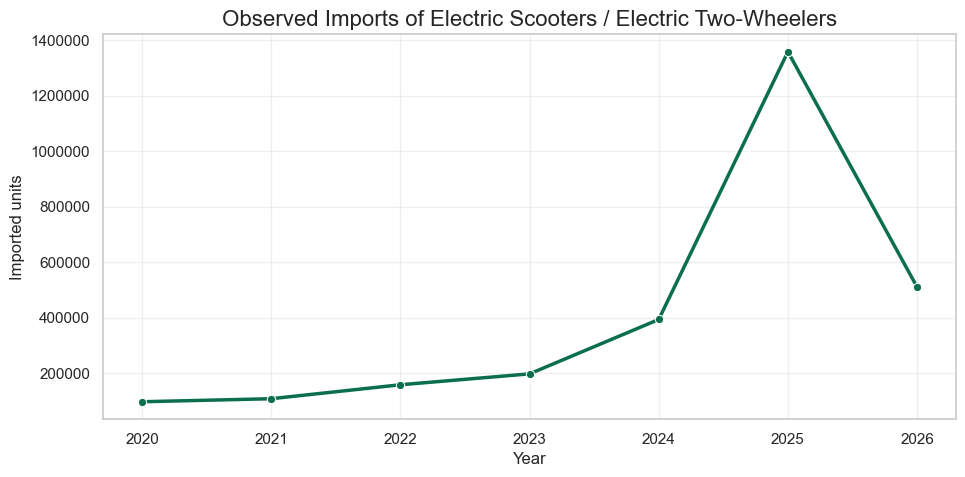

year,imports
2020,"96,242"
2021,"107,163"
2022,"157,487"
2023,"196,783"
2024,"392,903"
2025,"1,358,284"


In [38]:
market_full_year = (
    market_national[
        ~market_national["partial_year"]
    ]
    .copy()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=market_national,
    x="year",
    y="imports",
    marker="o",
    linewidth=2.5,
    color="#0B6E4F",
)

plt.title(
    "Observed Imports of Electric Scooters / Electric Two-Wheelers",
    fontsize=16,
)

plt.xlabel("Year")
plt.ylabel("Imported units")

plt.grid(
    alpha=0.3,
)

plt.grid(
    alpha=0.3,
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.show()

market_growth_display = (
    market_national.loc[
        market_national["year"].between(2020, 2025),
        [
            "year",
            "imports",
        ],
    ]
    .copy()
)

display(
    market_growth_display
    .style
    .format(
        {
            "imports": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

growth_multiple = (
    market_full_year["imports"].iloc[-1]
    / market_full_year["imports"].iloc[0]
)

> Interpretation
> * The Brazilian electric scooter market shows strong observed expansion throughout the analyzed period.
> * Imports increase from approximately 96 thousand units in 2020 to more than 1.35 million units in 2025, representing roughly 14x market growth.
> * The growth pattern appears nonlinear rather than gradual, suggesting a transition from early-stage adoption toward broader market scaling after 2023.
> * The 2026 observations are interpreted cautiously because they may represent a partial-year series rather than a completed annual period.

## 6.2 Market Acceleration and CAGR

This step evaluates how quickly the electric scooter market has been expanding over time.

Rather than analyzing only absolute import volume, the focus here is on:

- year-over-year market acceleration
- and long-term compounded growth behavior.

### Business Questions

- Is market growth stable or accelerating?
- How intense is the long-term expansion trend?
- Does the market show signs of structural scaling?

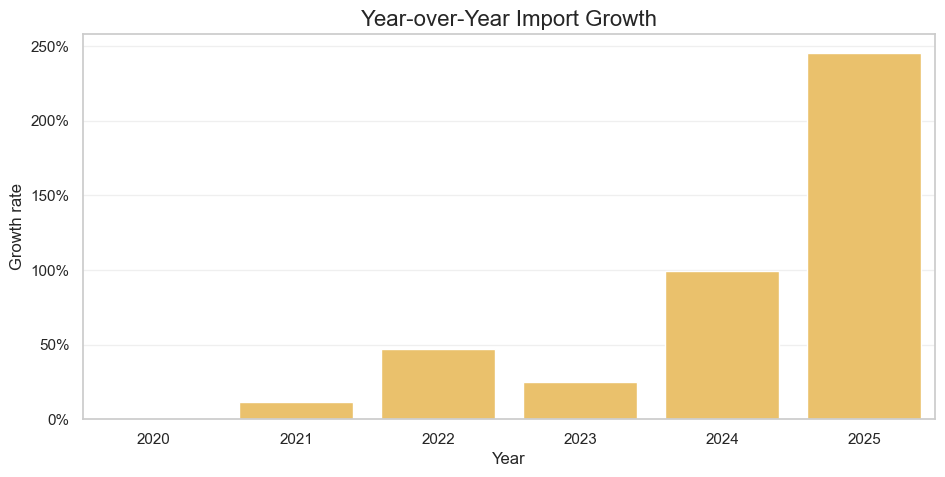

year,growth
2021,11.3%
2022,47.0%
2023,25.0%
2024,99.7%
2025,245.7%


In [40]:
cagr = (
    (
        market_full_year["imports"].iloc[-1]
        / market_full_year["imports"].iloc[0]
    )
    ** (
        1 / (len(market_full_year) - 1)
    )
    - 1
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=market_full_year,
    x="year",
    y="growth",
    color="#FFC857",
)

plt.title(
    "Year-over-Year Import Growth",
    fontsize=16,
)

plt.xlabel("Year")
plt.ylabel("Growth rate")

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.show()

growth_display = (
    market_full_year.loc[
        market_full_year["growth"].notna(),
        [
            "year",
            "growth",
        ],
    ]
    .copy()
)

display(
    growth_display
    .style
    .format(
        {
            "growth": "{:.1%}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The Brazilian electric scooter market does not grow at a constant rate; instead, the expansion accelerates sharply after 2023.
> * Year-over-year growth reaches nearly 100% in 2024 and exceeds 245% in 2025, suggesting a possible structural scaling phase rather than gradual organic growth alone.
> * The estimated CAGR between 2020 and 2025 is approximately 69.8% per year, indicating an exceptionally fast-growing market during the analyzed period.

## 6.3 Digital Demand and Search Interest

This step evaluates whether digital search behavior shows evidence of rising consumer awareness around electric scooters in Brazil.

Google Trends is used here as a proxy for:

- consumer curiosity
- product discovery
- and potential early-stage demand formation.

### Business Questions

- Is search interest increasing over time?
- Does digital demand accelerate alongside observed market growth?
- What types of scooter-related products are gaining attention?

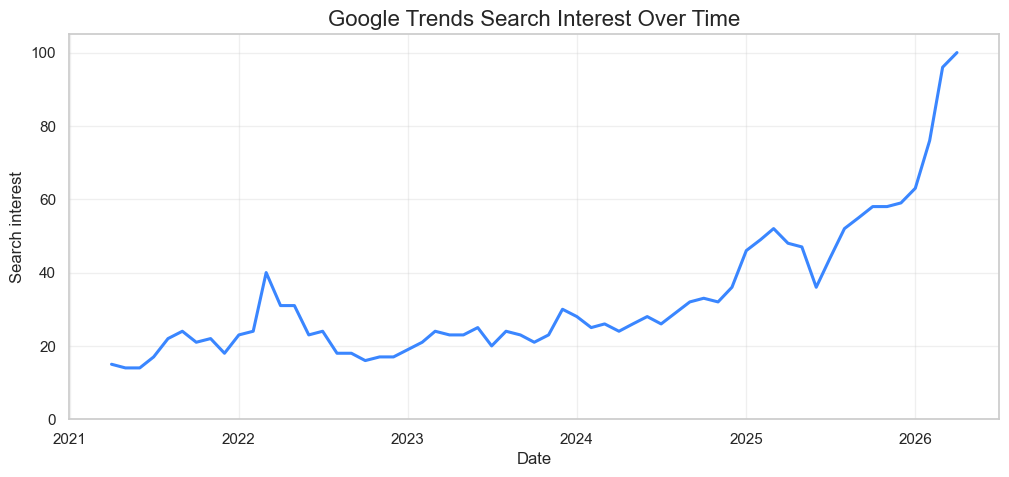

year,trends_avg,trends_max
2021,18.6,24
2022,23.5,40
2023,23.0,30
2024,28.8,36
2025,50.3,59


### Top Google Queries

query,search_interest,variation
moto elétrica scooter,100,-4%
moto,98,-10%
scooter moto,96,-9%
moto elétrica,94,-10%
moto scooter,94,-7%
moto scooter elétrica,93,-10%
scooter eletrica,81,-20%
bicicleta elétrica,47,-20%
bicicleta scooter elétrica,45,-20%
bicicleta elétrica scooter,44,-20%


### Rising Google Queries

query,search_interest,variation
scooter elétrica jet 1000w,2,Breakout
scooter elétrica 2000w gloov,1,Breakout
bike scooter elétrica harley citycoco 1500w,0,Breakout
scooter elétrica jet,4,"1,700%"
scooter elétrica x12,5,850%
motinho elétrica,1,300%
scooter elétrica 1000w,20,300%
scooter eletrica shineray,3,300%
shineray eletrica,3,250%
scooter shineray elétrica,7,250%


In [42]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=trends,
    x="date",
    y="trends",
    linewidth=2.2,
    color="#3A86FF",
)

plt.title(
    "Google Trends Search Interest Over Time",
    fontsize=16,
)

plt.xlabel("Date")
plt.ylabel("Search interest")

plt.grid(
    alpha=0.3,
)

plt.ylim(0, 105)

plt.show()

trends_display = (
    market_national.loc[
        market_national["year"].between(2021, 2025),
        [
            "year",
            "trends_avg",
            "trends_max",
        ],
    ]
    .copy()
)

display(
    trends_display
    .style
    .format(
        {
            "trends_avg": "{:.1f}",
            "trends_max": "{:.0f}",
        }
    )
    .hide(axis="index")
)

display(Markdown("### Top Google Queries"))

display(
    top_q.head(10)
    .style
    .hide(axis="index")
)

display(Markdown("### Rising Google Queries"))

display(
    rising_q.head(10)
    .style
    .hide(axis="index")
)

> Interpretation
> * Google search interest increases substantially after 2024, suggesting accelerating consumer awareness around electric scooters and related mobility products.
> * The digital-demand pattern broadly follows the same acceleration observed in import growth, reinforcing the hypothesis that market expansion is accompanied by rising public attention.
> * The rising-query dataset also suggests growing consumer interest in more specific and higher-powered scooter models rather than only generic product searches.
> * Because Google Trends measures relative search intensity rather than direct purchases, the indicators are interpreted as demand-awareness proxies rather than observed market transactions.

## 6.4 Import Price Dynamics

This step investigates how the average import price per unit evolves over time alongside market expansion.

Price behavior is important because it may help explain whether market growth is being driven by:

- premium adoption
- broader affordability
- or large-scale market democratization.

### Business Questions

- Are import prices increasing or decreasing over time?
- Does market expansion coincide with lower unit prices?
- Is there evidence of market commoditization as adoption accelerates?

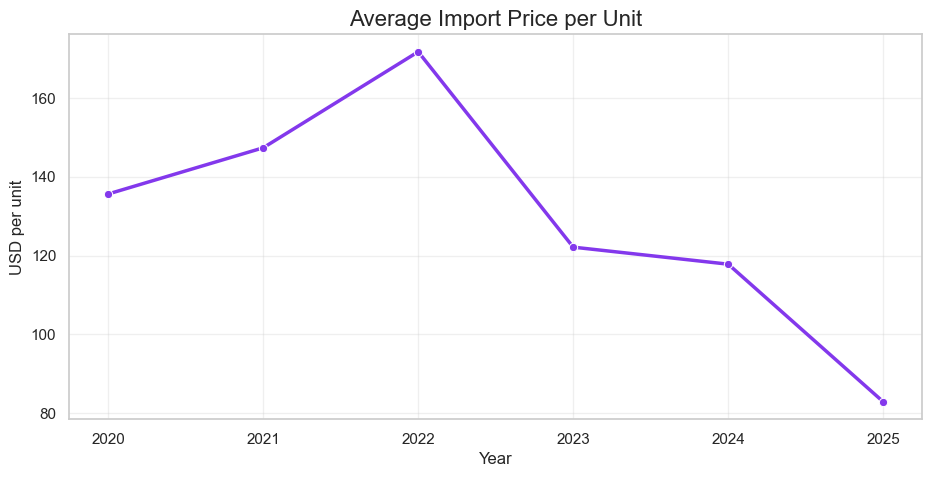

year,avg_price_usd
2020,$135.62
2021,$147.34
2022,$171.73
2023,$122.12
2024,$117.80
2025,$82.87


In [44]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=market_full_year,
    x="year",
    y="avg_price_usd",
    marker="o",
    linewidth=2.5,
    color="#8338EC",
)

plt.title(
    "Average Import Price per Unit",
    fontsize=16,
)

plt.xlabel("Year")
plt.ylabel("USD per unit")

plt.grid(
    alpha=0.3,
)

plt.show()

price_display = (
    market_full_year[
        [
            "year",
            "avg_price_usd",
        ]
    ]
    .copy()
)

display(
    price_display
    .style
    .format(
        {
            "avg_price_usd": "${:,.2f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * Average import prices rise between 2020 and 2022 before declining sharply during the market-expansion phase after 2023.
> * The combination of accelerating import volume and falling unit prices may indicate increasing market accessibility and possible commoditization effects.
> * The strong negative correlation between import volume and average unit price suggests that larger-scale adoption coincides with lower average import costs.
> * Although price declines alone cannot fully explain market growth, the pattern is consistent with a transition from niche premium products toward broader consumer-market penetration.

## 6.5 Search Query Signals

This final exploratory step investigates the specific search terms associated with electric scooters in Brazil.

Rather than focusing only on total search volume, the analysis examines:

- the most common search patterns
- rising product-related terms
- and signs of evolving consumer interest.

### Business Questions

- What types of electric mobility products attract the most attention?
- Are consumers searching generically or for specific models and brands?
- Do search patterns suggest increasing market sophistication?

In [46]:
top_queries_display = (
    top_q.head(10)
    .copy()
)

rising_queries_display = (
    rising_q.head(10)
    .copy()
)

display(Markdown("### Most Common Search Queries"))

display(
    top_queries_display
    .style
    .hide(axis="index")
)

display(Markdown("### Fastest Rising Search Queries"))

display(
    rising_queries_display
    .style
    .hide(axis="index")
)

### Most Common Search Queries

query,search_interest,variation
moto elétrica scooter,100,-4%
moto,98,-10%
scooter moto,96,-9%
moto elétrica,94,-10%
moto scooter,94,-7%
moto scooter elétrica,93,-10%
scooter eletrica,81,-20%
bicicleta elétrica,47,-20%
bicicleta scooter elétrica,45,-20%
bicicleta elétrica scooter,44,-20%


### Fastest Rising Search Queries

query,search_interest,variation
scooter elétrica jet 1000w,2,Breakout
scooter elétrica 2000w gloov,1,Breakout
bike scooter elétrica harley citycoco 1500w,0,Breakout
scooter elétrica jet,4,"1,700%"
scooter elétrica x12,5,850%
motinho elétrica,1,300%
scooter elétrica 1000w,20,300%
scooter eletrica shineray,3,300%
shineray eletrica,3,250%
scooter shineray elétrica,7,250%


> Interpretation
> * The most frequent search terms remain relatively broad and category-oriented, suggesting that many consumers are still exploring and discovering electric mobility products.
> * At the same time, the rising-query dataset reveals increasing attention toward specific scooter models, power specifications, and recognizable brands.
> * Queries involving terms such as “1000w”, “2000w”, and “Shineray” suggest a transition from generic curiosity toward more intentional product evaluation behavior.
> * Together, the search-query patterns indicate that the market may be evolving from early awareness into a more mature product-comparison and purchase-consideration phase.

# 7. Regional Analysis

This section investigates how economic capacity, population concentration, and two-wheel mobility infrastructure vary across Brazilian regions.

Because state-level scooter adoption data is unavailable, the analysis focuses on identifying where long-term market opportunity is likely to be strongest based on structural regional indicators.

The goal is not to measure realized adoption by region, but rather to evaluate relative market readiness and mobility intensity across Brazil.

## 7.1 Regional Economic Concentration

This step evaluates how economic activity, population, and two-wheel fleet infrastructure are distributed across Brazilian regions.

The comparison helps identify whether market opportunity is concentrated primarily in large economic centers or spread more broadly across mobility-intensive regions.

### Business Questions

- Which regions concentrate the largest economic capacity?
- How concentrated is the two-wheel fleet?
- Do population and mobility distribution follow the same regional pattern?

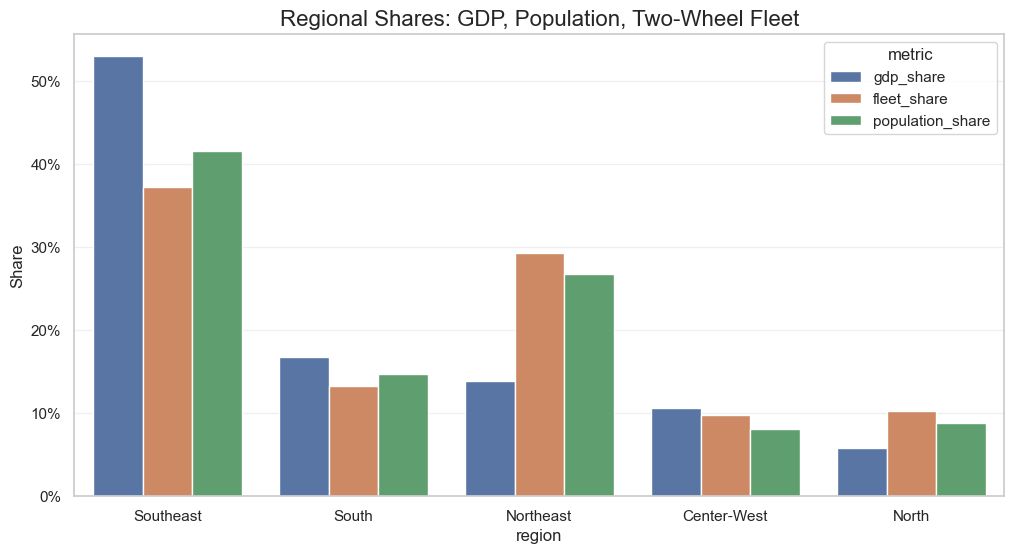

region,gdp_share,population_share,fleet_share
Southeast,53.0%,41.6%,37.2%
South,16.8%,14.7%,13.3%
Northeast,13.8%,26.8%,29.3%
Center-West,10.6%,8.1%,9.8%
North,5.8%,8.8%,10.3%


In [47]:
regional_plot = (
    regional_snapshot
    .sort_values(
        "gdp_2023",
        ascending=False,
    )
    .copy()
)

regional_plot_melt = regional_plot.melt(
    id_vars="region",
    value_vars=[
        "gdp_share",
        "fleet_share",
        "population_share",
    ],
    var_name="metric",
    value_name="share",
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=regional_plot_melt,
    x="region",
    y="share",
    hue="metric",
)

plt.title(
    "Regional Shares: GDP, Population, Two-Wheel Fleet",
    fontsize=16,
)

plt.ylabel("Share")

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.show()

display(
    regional_snapshot[
        [
            "region",
            "gdp_share",
            "population_share",
            "fleet_share",
        ]
    ]
    .sort_values(
        "gdp_share",
        ascending=False,
    )
    .style
    .format(
        {
            "gdp_share": "{:.1%}",
            "population_share": "{:.1%}",
            "fleet_share": "{:.1%}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The Southeast dominates Brazil's economic structure, concentrating more than half of total regional GDP while also maintaining the country's largest two-wheel fleet.
> * The Northeast stands out as a mobility-intensive region, combining a disproportionately large fleet share relative to its economic participation.
> * The comparison suggests that long-term electric scooter opportunity may emerge from different structural drivers depending on the region: purchasing power in the Southeast versus mobility familiarity in regions such as the Northeast.

## 7.2 Mobility Intensity by Region

This step evaluates the relative intensity of two-wheel mobility across Brazilian regions using fleet-per-capita indicators.

While absolute fleet size measures scale, fleet intensity helps identify regions where two-wheel transportation is more deeply embedded in everyday mobility behavior.

### Business Questions

- Which regions show the strongest two-wheel mobility culture?
- Are mobility-intensive regions the same as the richest regions?
- Could high mobility familiarity support future scooter adoption?

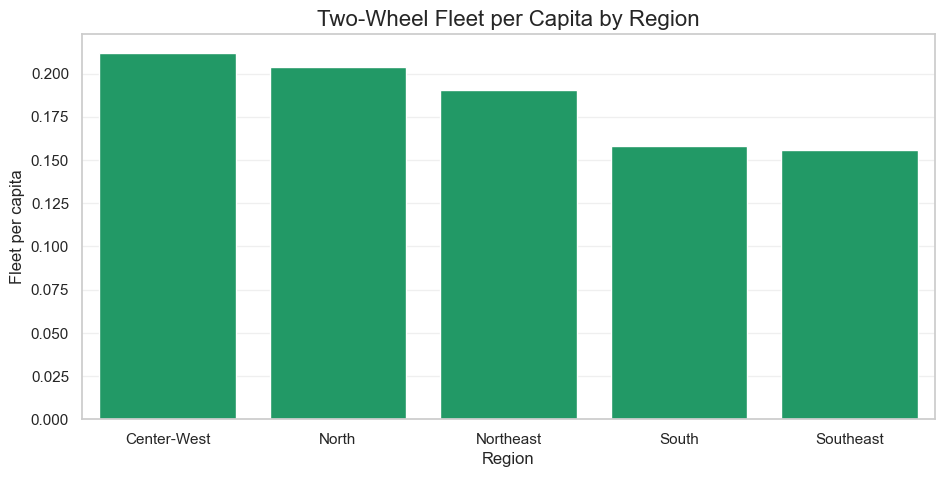

region,fleet_pc,gdp_pc
Center-West,0.212,"R$67,280"
North,0.204,"R$33,857"
Northeast,0.191,"R$26,431"
South,0.158,"R$58,587"
Southeast,0.156,"R$65,291"


In [48]:
regional_fleet_pc = (
    regional_snapshot
    .sort_values(
        "fleet_pc",
        ascending=False,
    )
    .copy()
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=regional_fleet_pc,
    x="region",
    y="fleet_pc",
    color="#0EAD69",
)

plt.title(
    "Two-Wheel Fleet per Capita by Region",
    fontsize=16,
)

plt.xlabel("Region")
plt.ylabel("Fleet per capita")

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.show()

display(
    regional_fleet_pc[
        [
            "region",
            "fleet_pc",
            "gdp_pc",
        ]
    ]
    .style
    .format(
        {
            "fleet_pc": "{:.3f}",
            "gdp_pc": "R${:,.0f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The Center-West, North, and Northeast show the highest two-wheel fleet intensity relative to population size.
> * These regions do not necessarily have the strongest purchasing power, but they appear to have stronger structural familiarity with two-wheel mobility behavior.
> * The contrast between GDP concentration and mobility intensity suggests that electric scooter opportunity may emerge through different adoption dynamics depending on the region.
> * In higher-income regions, adoption may be driven more by purchasing power and urban convenience, while in mobility-intensive regions, adoption may benefit from preexisting transportation habits.

## 7.3 Regional Opportunity Interpretation

This final regional-analysis step translates the structural indicators into market-opportunity interpretation.

Rather than identifying where scooter adoption is already highest, the goal is to evaluate which regions appear structurally favorable for future expansion based on:

- purchasing power
- mobility familiarity
- and population concentration.

### Business Questions

- Which regions appear most structurally attractive for expansion?
- Are the strongest opportunities concentrated in mature or emerging regions?
- What trade-offs exist between economic power and mobility intensity?

In [49]:
regional_opportunity = (
    regional_snapshot[
        [
            "region",
            "gdp_share",
            "population_share",
            "fleet_share",
            "gdp_pc",
            "fleet_pc",
        ]
    ]
    .copy()
)

regional_opportunity["opportunity_profile"] = [
    "Economic scale leader",
    "Balanced mature market",
    "Mobility-intensive emerging market",
    "High-intensity niche market",
    "Mobility-driven emerging market",
]

display(
    regional_opportunity
    .style
    .format(
        {
            "gdp_share": "{:.1%}",
            "population_share": "{:.1%}",
            "fleet_share": "{:.1%}",
            "gdp_pc": "R${:,.0f}",
            "fleet_pc": "{:.3f}",
        }
    )
    .hide(axis="index")
)

region,gdp_share,population_share,fleet_share,gdp_pc,fleet_pc,opportunity_profile
Southeast,53.0%,41.6%,37.2%,"R$65,291",0.156,Economic scale leader
South,16.8%,14.7%,13.3%,"R$58,587",0.158,Balanced mature market
Northeast,13.8%,26.8%,29.3%,"R$26,431",0.191,Mobility-intensive emerging market
Center-West,10.6%,8.1%,9.8%,"R$67,280",0.212,High-intensity niche market
North,5.8%,8.8%,10.3%,"R$33,857",0.204,Mobility-driven emerging market


> Interpretation
> * The Southeast remains the country's dominant large-scale opportunity region due to its combination of economic concentration, population scale, and overall fleet size.
> * The Northeast emerges as a particularly important mobility-intensive market, combining a large population base with disproportionately high two-wheel fleet participation relative to GDP share.
> * The Center-West stands out as a smaller but structurally attractive region because it combines the country’s highest fleet intensity with the highest GDP per capita.
> * Overall, the regional analysis suggests that future scooter expansion may not depend exclusively on income concentration, but also on preexisting mobility behavior and transportation culture.

# 8. Per Capita Analysis

This section investigates which Brazilian states appear structurally favorable for electric scooter expansion on a per-capita basis.

Because direct scooter adoption by state is unavailable, the analysis focuses on proxy indicators related to:

- purchasing power
- mobility intensity
- and overall market-readiness potential.

The goal is not to estimate realized adoption, but rather to identify states where the structural conditions for future growth appear strongest.

## 8.1 High-Income States

This step identifies the Brazilian states with the highest GDP per capita levels.

Higher GDP per capita may indicate:
- stronger purchasing power
- greater affordability for premium mobility products
- and potentially stronger adoption capacity for higher-value electric vehicles.

### Business Questions

- Which states show the strongest purchasing power?
- Are the richest states concentrated in specific regions?
- Could higher-income states support faster premium-market adoption?

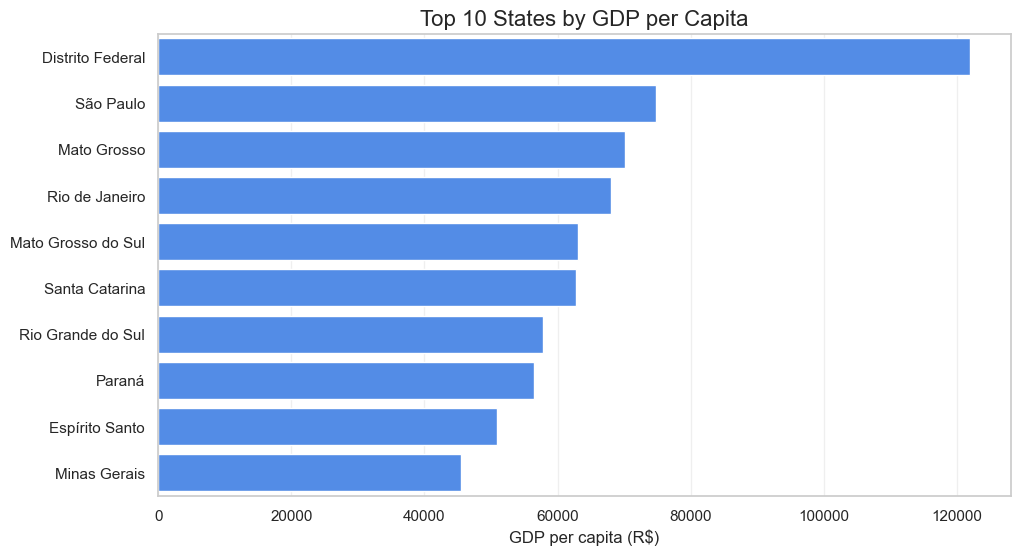

state,gdp_pc
Distrito Federal,"R$122,016"
São Paulo,"R$74,754"
Mato Grosso,"R$70,116"
Rio de Janeiro,"R$68,097"
Mato Grosso do Sul,"R$63,051"
Santa Catarina,"R$62,708"
Rio Grande do Sul,"R$57,873"
Paraná,"R$56,425"
Espírito Santo,"R$50,845"
Minas Gerais,"R$45,433"


In [50]:
top_gdp_pc = (
    state_snapshot
    .sort_values(
        "gdp_pc",
        ascending=False,
    )[
        [
            "state",
            "gdp_pc",
        ]
    ]
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_gdp_pc,
    y="state",
    x="gdp_pc",
    color="#3A86FF",
)

plt.title(
    "Top 10 States by GDP per Capita",
    fontsize=16,
)

plt.xlabel("GDP per capita (R$)")
plt.ylabel("")

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.show()

display(
    top_gdp_pc
    .style
    .format(
        {
            "gdp_pc": "R${:,.0f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The highest GDP-per-capita states are concentrated primarily in the Southeast, South, and Center-West regions.
> * Distrito Federal stands out substantially above all other states, while São Paulo, Mato Grosso, and Rio de Janeiro also show strong purchasing-power indicators.
> * Higher-income states may offer stronger short-term adoption potential for premium electric mobility products due to greater consumer affordability.
> * However, purchasing power alone does not fully explain mobility behavior, making it important to compare these states against mobility-intensity indicators in the next step.

## 8.2 High Mobility-Intensity States

This step identifies the Brazilian states with the highest two-wheel fleet intensity relative to population size.

High fleet-per-capita values may indicate:
- stronger cultural familiarity with two-wheel transportation
- greater mobility dependence
- and potentially lower behavioral friction for electric scooter adoption.

### Business Questions

- Which states show the strongest two-wheel mobility intensity?
- Are high-intensity states also the richest states?
- Could mobility familiarity accelerate future scooter adoption?

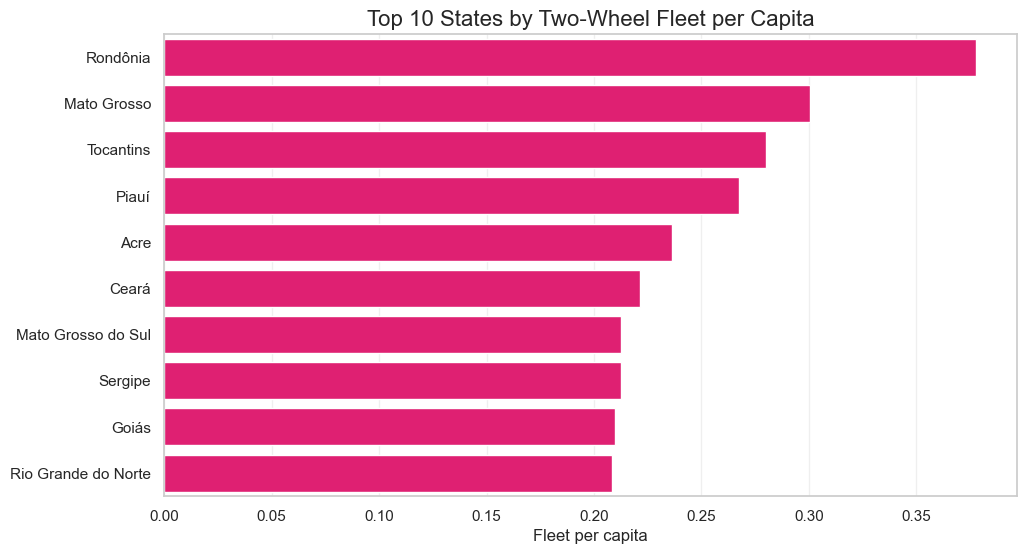

state,fleet_pc
Rondônia,0.378
Mato Grosso,0.300
Tocantins,0.280
Piauí,0.268
Acre,0.236
Ceará,0.222
Mato Grosso do Sul,0.213
Sergipe,0.213
Goiás,0.210
Rio Grande do Norte,0.208


In [51]:
top_fleet_pc = (
    state_snapshot
    .sort_values(
        "fleet_pc",
        ascending=False,
    )[
        [
            "state",
            "fleet_pc",
        ]
    ]
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_fleet_pc,
    y="state",
    x="fleet_pc",
    color="#FF006E",
)

plt.title(
    "Top 10 States by Two-Wheel Fleet per Capita",
    fontsize=16,
)

plt.xlabel("Fleet per capita")
plt.ylabel("")

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.show()

display(
    top_fleet_pc
    .style
    .format(
        {
            "fleet_pc": "{:.3f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The states with the highest two-wheel fleet intensity are concentrated primarily in the North, Northeast, and Center-West regions.
> * Rondônia, Mato Grosso, and Tocantins stand out as particularly mobility-intensive states, suggesting strong structural familiarity with two-wheel transportation behavior.
> * Several of these states are not among the country’s richest economies, reinforcing the idea that mobility intensity and purchasing power represent different market dynamics.
> * The combination of high fleet intensity and moderate-to-high income levels in states such as Mato Grosso and Goiás may indicate especially attractive long-term adoption environments.

## 8.3 Market Opportunity Proxy

This step combines purchasing power and mobility intensity into a simplified market-opportunity proxy.

Because direct scooter adoption data by state is unavailable, the proxy is designed to estimate where structural conditions for future market expansion may be strongest.

The proxy combines:

- economic scale
- purchasing power
- and two-wheel mobility familiarity.

### Business Questions

- Which states appear structurally strongest for future scooter expansion?
- Do the largest opportunities emerge from mature or emerging markets?
- Which states combine both economic capacity and mobility readiness?

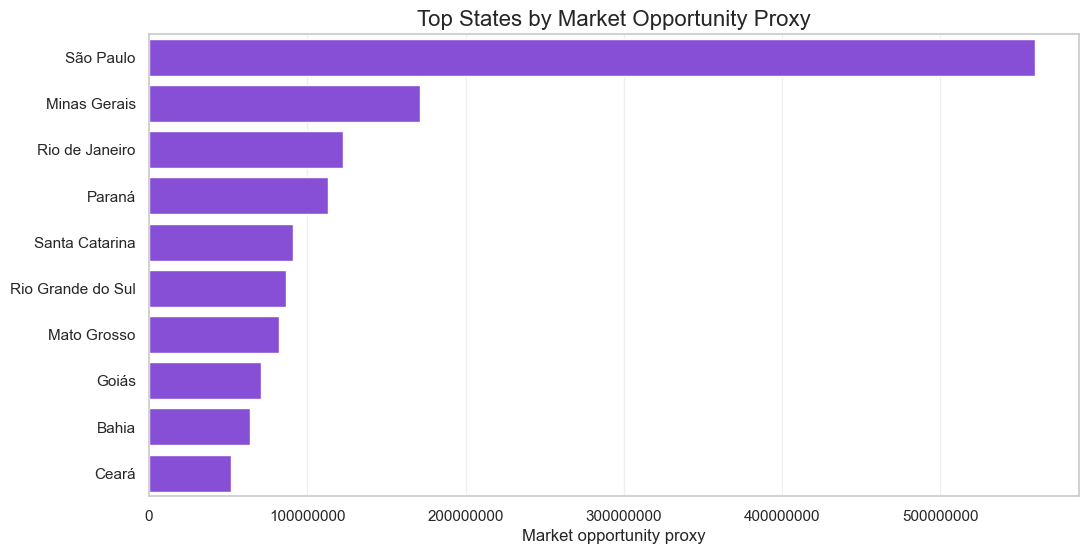

state,market_size_proxy,cons_pc
São Paulo,"559,586,524","12,143"
Minas Gerais,"170,990,148","7,993"
Rio de Janeiro,"122,781,569","7,129"
Paraná,"113,015,735","9,505"
Santa Catarina,"91,076,419","11,124"
Rio Grande do Sul,"86,765,698","7,724"
Mato Grosso,"82,034,766","21,069"
Goiás,"70,678,213","9,521"
Bahia,"63,607,290","4,277"
Ceará,"51,474,741","5,554"


In [52]:
top_market_proxy = (
    state_snapshot
    .sort_values(
        "market_size_proxy",
        ascending=False,
    )[
        [
            "state",
            "market_size_proxy",
            "cons_pc",
        ]
    ]
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_market_proxy,
    y="state",
    x="market_size_proxy",
    color="#8338EC",
)

plt.title(
    "Top States by Market Opportunity Proxy",
    fontsize=16,
)

plt.xlabel("Market opportunity proxy")
plt.ylabel("")

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.ticklabel_format(
    style="plain",
    axis="x",
)

plt.show()

display(
    top_market_proxy
    .style
    .format(
        {
            "market_size_proxy": "{:,.0f}",
            "cons_pc": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * São Paulo remains the dominant large-scale opportunity state due to its combination of economic scale, population concentration, and strong mobility infrastructure.
> * Minas Gerais, Paraná, Santa Catarina, and Rio de Janeiro also appear as structurally strong mature-market environments.
> * Mato Grosso stands out as one of the most interesting hybrid opportunity states because it combines high purchasing power with exceptionally strong mobility intensity.
> * The proxy results suggest that future scooter expansion may emerge through both large mature economies and smaller high-intensity mobility markets.

## 8.4 Mature vs Emerging Market Interpretation

This final per-capita analysis step compares mature large-scale markets against emerging high-intensity mobility markets.

The goal is to understand whether future electric scooter expansion in Brazil is likely to be driven primarily by:

- large mature economies
- or smaller but mobility-intensive regions.

### Business Questions

- Are the strongest opportunities concentrated in mature or emerging markets?
- Which states combine scale with mobility readiness?
- Could emerging mobility-intensive states become important future expansion markets?

In [53]:
market_profiles = pd.DataFrame(
    [
        {
            "Market Type": "Mature large-scale markets",
            "Representative States": "São Paulo, Minas Gerais, Rio de Janeiro, Paraná",
            "Main Characteristics": "Large economic scale and purchasing power",
        },
        {
            "Market Type": "Balanced mature markets",
            "Representative States": "Santa Catarina, Rio Grande do Sul, Goiás",
            "Main Characteristics": "Strong balance between income and mobility intensity",
        },
        {
            "Market Type": "Emerging mobility-intensive markets",
            "Representative States": "Mato Grosso, Tocantins, Ceará, Rondônia",
            "Main Characteristics": "High fleet intensity and growing structural readiness",
        },
    ]
)

display(
    market_profiles
    .style
    .hide(axis="index")
)

display(Markdown("### High-Readiness Hybrid States"))

hybrid_states = (
    state_snapshot.loc[
        state_snapshot["state"].isin(
            [
                "Mato Grosso",
                "Goiás",
                "Santa Catarina",
                "Mato Grosso do Sul",
            ]
        ),
        [
            "state",
            "gdp_pc",
            "fleet_pc",
            "cons_pc",
        ],
    ]
    .sort_values(
        "cons_pc",
        ascending=False,
    )
)

display(
    hybrid_states
    .style
    .format(
        {
            "gdp_pc": "R${:,.0f}",
            "fleet_pc": "{:.3f}",
            "cons_pc": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

Market Type,Representative States,Main Characteristics
Mature large-scale markets,"São Paulo, Minas Gerais, Rio de Janeiro, Paraná",Large economic scale and purchasing power
Balanced mature markets,"Santa Catarina, Rio Grande do Sul, Goiás",Strong balance between income and mobility intensity
Emerging mobility-intensive markets,"Mato Grosso, Tocantins, Ceará, Rondônia",High fleet intensity and growing structural readiness


### High-Readiness Hybrid States

state,gdp_pc,fleet_pc,cons_pc
Mato Grosso,"R$70,116",0.300,"21,069"
Mato Grosso do Sul,"R$63,051",0.213,"13,417"
Santa Catarina,"R$62,708",0.177,"11,124"
Goiás,"R$45,362",0.210,"9,521"


> Interpretation
> * The analysis suggests that future electric scooter expansion in Brazil may emerge through multiple structural pathways rather than a single dominant market profile.
> * Large mature economies such as São Paulo and Minas Gerais offer scale, purchasing power, and infrastructure advantages.
> * At the same time, emerging mobility-intensive states such as Mato Grosso and Rondônia appear structurally attractive because they combine strong two-wheel transportation culture with rising economic capacity.
> * The strongest long-term opportunities may therefore emerge in hybrid environments where mobility familiarity and purchasing power coexist simultaneously.

# 9. Correlation & Explanatory Analysis

This section investigates which structural indicators appear most strongly associated with market growth and market-opportunity potential.

Because state-level observed scooter adoption is unavailable, the analysis separates:

- national demand relationships
- from state-level structural opportunity relationships.

The goal is not to claim causality, but rather to evaluate whether the available indicators behave consistently with the broader market-expansion narrative developed throughout the notebook.

## 9.1 National Demand Correlations

This step evaluates whether digital demand indicators and pricing dynamics move consistently with observed national market growth.

The analysis focuses on correlations between:
- imports
- Google Trends behavior
- lead demand indicators
- and average import prices.

### Business Questions

- Does digital interest move alongside observed market demand?
- Do lead search indicators show predictive potential?
- Is market expansion associated with lower average prices?

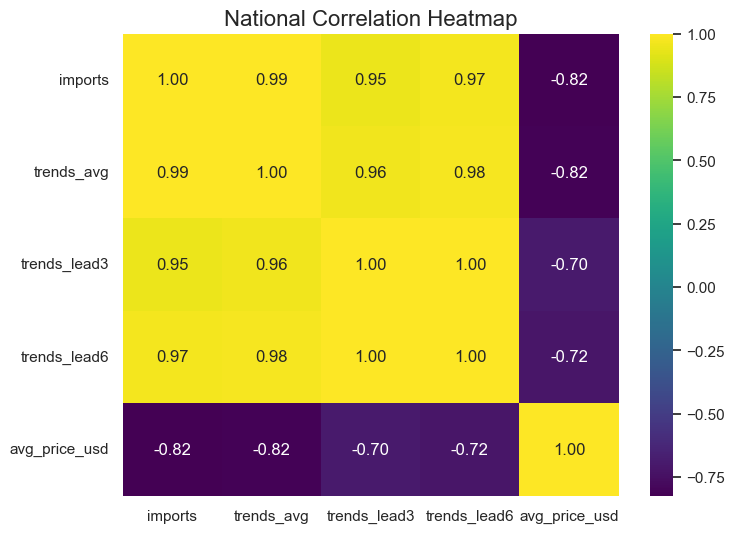

feature,pearson,spearman,n_obs
trends_avg,0.993,0.900,5
trends_lead6,0.967,0.800,4
trends_lead3,0.946,0.800,4
avg_price_usd,-0.823,-0.771,6


In [54]:
def spearman_corr(a, b):
    return (
        pd.Series(a)
        .rank()
        .corr(
            pd.Series(b).rank(),
            method="pearson",
        )
    )


national_corr = []

for feature in [
    "trends_avg",
    "trends_lead3",
    "trends_lead6",
    "avg_price_usd",
]:
    sample = (
        market_full_year[
            [
                "imports",
                feature,
            ]
        ]
        .dropna()
    )

    national_corr.append(
        {
            "feature": feature,
            "pearson": sample["imports"].corr(
                sample[feature]
            ),
            "spearman": spearman_corr(
                sample["imports"],
                sample[feature],
            ),
            "n_obs": len(sample),
        }
    )

national_corr = (
    pd.DataFrame(national_corr)
    .sort_values(
        "pearson",
        ascending=False,
    )
)

plt.figure(figsize=(8, 6))

corr_heatmap = (
    market_full_year[
        [
            "imports",
            "trends_avg",
            "trends_lead3",
            "trends_lead6",
            "avg_price_usd",
        ]
    ]
    .corr()
)

sns.heatmap(
    corr_heatmap,
    annot=True,
    cmap="viridis",
    fmt=".2f",
)

plt.title(
    "National Correlation Heatmap",
    fontsize=16,
)

plt.show()

display(
    national_corr
    .style
    .format(
        {
            "pearson": "{:.3f}",
            "spearman": "{:.3f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * National import growth shows extremely strong positive correlation with Google Trends indicators in this dataset.
> * Both same-year and lead search-interest measures move closely alongside observed import acceleration, suggesting that digital demand may contain useful early market signals.
> * Average import price shows a strong negative relationship with imports, reinforcing the earlier evidence that market expansion coincides with falling average unit prices.
> * Because the national dataset contains relatively few annual observations, the correlations are interpreted as exploratory structural signals rather than definitive causal evidence.

## 9.2 State Opportunity Relationships

This step evaluates whether state-level economic and mobility indicators behave consistently with the market-opportunity structures developed earlier in the notebook.

Because direct scooter adoption by state is unavailable, the analysis focuses on relationships between:
- GDP
- purchasing power
- mobility intensity
- and the engineered market-opportunity proxy.

### Business Questions

- Does economic scale relate strongly to market opportunity?
- Does mobility infrastructure contribute to structural readiness?
- Are mobility intensity and economic power equally important?

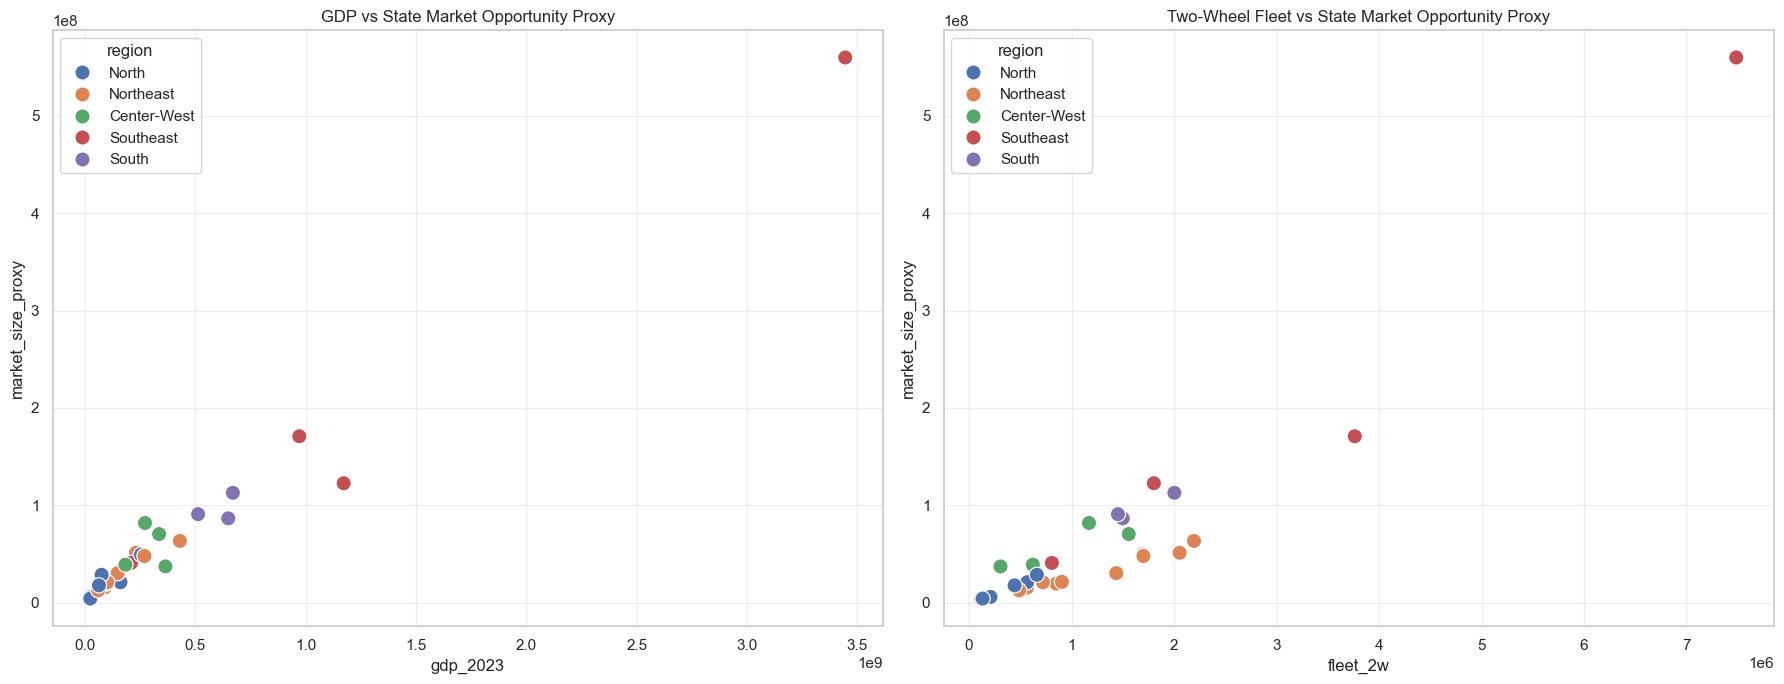

feature,pearson,spearman,n_obs
gdp_2023,0.987,0.955,27
fleet_2w,0.951,0.875,27
gdp_pc,0.387,0.541,27
fleet_pc,-0.202,-0.297,27


In [55]:
state_corr = []

for feature in [
    "gdp_2023",
    "gdp_pc",
    "fleet_2w",
    "fleet_pc",
]:
    sample = (
        state_snapshot[
            [
                feature,
                "market_size_proxy",
            ]
        ]
        .dropna()
    )

    state_corr.append(
        {
            "feature": feature,
            "pearson": sample[feature].corr(
                sample["market_size_proxy"]
            ),
            "spearman": spearman_corr(
                sample[feature],
                sample["market_size_proxy"],
            ),
            "n_obs": len(sample),
        }
    )

state_corr = (
    pd.DataFrame(state_corr)
    .sort_values(
        "pearson",
        ascending=False,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
)

sns.scatterplot(
    data=state_snapshot,
    x="gdp_2023",
    y="market_size_proxy",
    hue="region",
    s=120,
    ax=axes[0],
)

axes[0].set_title(
    "GDP vs State Market Opportunity Proxy"
)

sns.scatterplot(
    data=state_snapshot,
    x="fleet_2w",
    y="market_size_proxy",
    hue="region",
    s=120,
    ax=axes[1],
)

axes[1].set_title(
    "Two-Wheel Fleet vs State Market Opportunity Proxy"
)

plt.tight_layout()
plt.show()

display(
    state_corr
    .style
    .format(
        {
            "pearson": "{:.3f}",
            "spearman": "{:.3f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * State-level market opportunity shows an extremely strong positive relationship with both GDP scale and total two-wheel fleet size.
> * The results suggest that economic concentration and mobility infrastructure are both structurally important components of long-term market potential.
> * GDP per capita and fleet intensity show weaker relationships because they measure relative conditions rather than absolute market scale.
> * The analysis therefore suggests that large-scale opportunity depends primarily on market size and mobility infrastructure, while per-capita indicators help explain regional readiness and adoption dynamics.

## 9.3 Explanatory Interpretation and Limitations

The overall analysis suggests that electric scooter market expansion in Brazil is associated with a combination of:

- accelerating digital demand
- falling average import prices
- economic concentration
- and preexisting two-wheel mobility infrastructure.

At the national level, Google Trends indicators move very closely alongside realized import growth, suggesting that digital demand may function as an early structural signal of market acceleration.

At the regional and state levels, the analysis suggests that future expansion opportunities may emerge through different structural pathways:

- large mature economies driven by purchasing power and scale
- and mobility-intensive regions driven by transportation familiarity and behavioral readiness.

The results also suggest that mobility intensity alone does not fully explain large-scale opportunity. Instead, the strongest structural environments appear where economic capacity and mobility familiarity coexist simultaneously.

> **Important Methodological Limitations**
>
> Several limitations prevent the analysis from being interpreted causally:
>
> * the dataset does not include observed scooter adoption by state
> * the state-level opportunity indicators are engineered structural proxies
> * Google Trends measures search behavior rather than purchases
> * and the national time-series analysis relies on a relatively small number of annual observations.
>
> Because of this, the findings should be interpreted as exploratory structural evidence rather than definitive predictive proof.
>
> Even with these limitations, the relationships remain highly coherent across multiple analytical perspectives developed throughout the notebook.

# 10. Temporal Analysis (Lags)

This section investigates whether digital demand signals appear before periods of accelerated market growth.

The analysis compares realized annual imports against:
- same-year digital demand
- 3-month lead search interest
- and 6-month lead search interest.

### Business Questions

- Does digital interest precede market expansion?
- Are lead search indicators structurally associated with future demand?
- Which lag structure appears strongest in this dataset?

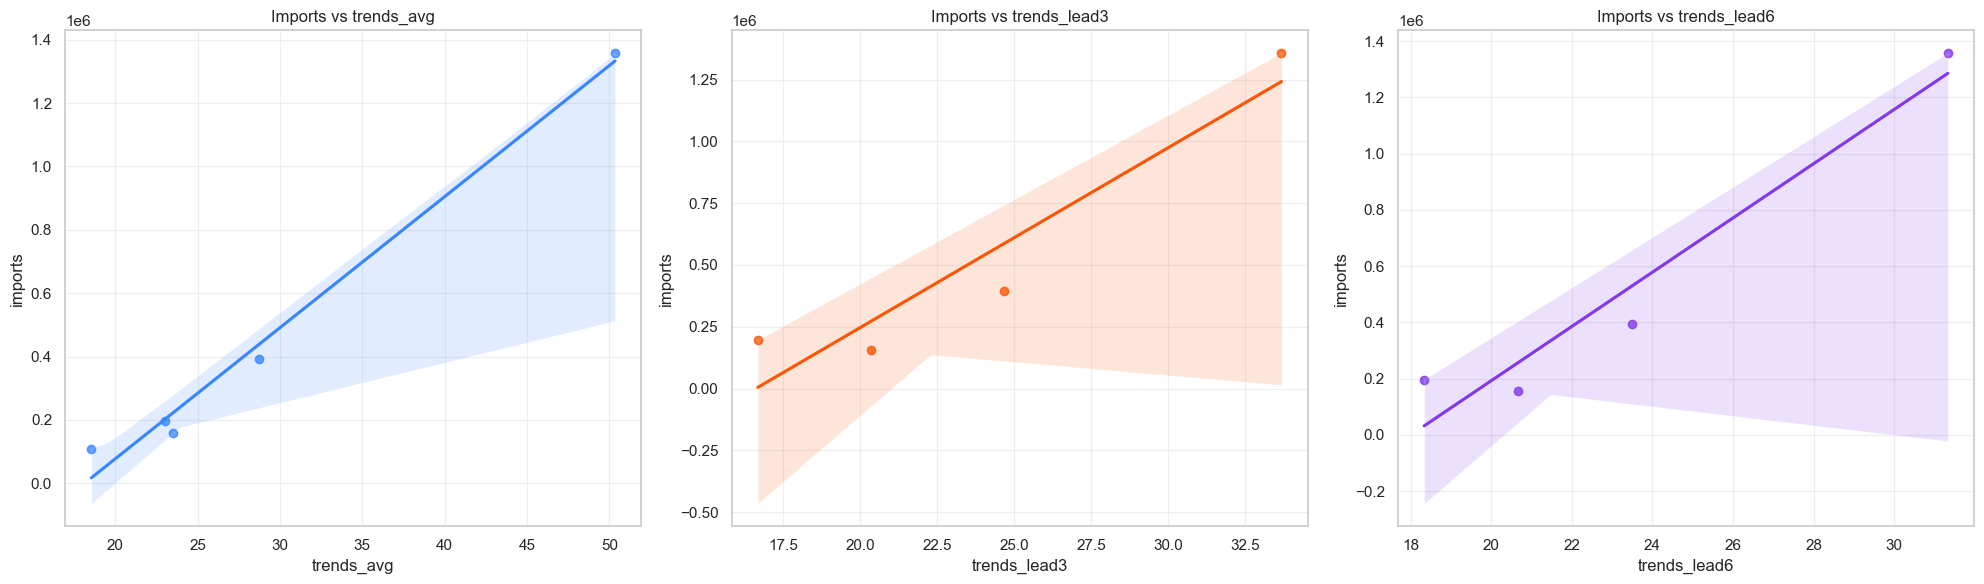

feature,pearson,spearman,n_obs
trends_avg,0.993,0.900,5
trends_lead6,0.967,0.800,4
trends_lead3,0.946,0.800,4


In [57]:
lag_corr = []

for feature in [
    "trends_avg",
    "trends_lead3",
    "trends_lead6",
]:
    sample = (
        market_full_year[
            [
                "imports",
                feature,
            ]
        ]
        .dropna()
    )

    lag_corr.append(
        {
            "feature": feature,
            "pearson": sample["imports"].corr(
                sample[feature]
            ),
            "spearman": spearman_corr(
                sample["imports"],
                sample[feature],
            ),
            "n_obs": len(sample),
        }
    )

lag_corr = (
    pd.DataFrame(lag_corr)
    .sort_values(
        "pearson",
        ascending=False,
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
)

for ax, feature, color in zip(
    axes,
    [
        "trends_avg",
        "trends_lead3",
        "trends_lead6",
    ],
    [
        "#3A86FF",
        "#FB5607",
        "#8338EC",
    ],
):
    sample = (
        market_full_year[
            [
                "year",
                "imports",
                feature,
            ]
        ]
        .dropna()
    )

    sns.regplot(
        data=sample,
        x=feature,
        y="imports",
        ax=ax,
        color=color,
    )

    ax.set_title(
        f"Imports vs {feature}"
    )

plt.tight_layout()
plt.show()

display(
    lag_corr
    .style
    .format(
        {
            "pearson": "{:.3f}",
            "spearman": "{:.3f}",
        }
    )
    .hide(axis="index")
)

> Interpretation
> * The lag analysis suggests that digital search behavior remains strongly associated with future periods of market expansion.
> * Both the 3-month and 6-month lead indicators maintain very high positive correlations with realized imports, even with fewer comparable observations.
> * The 6-month lead relationship appears slightly stronger than the 3-month lead relationship in this dataset, which is directionally consistent with the hypothesis that rising digital interest may precede future demand acceleration.
> * At the same time, the analysis remains exploratory because the annual import structure produces a very small lagged sample size.
> * The results should therefore be interpreted as suggestive structural evidence rather than definitive predictive validation.

# 11. Clustering

This section uses clustering to segment Brazilian states into market-readiness profiles based on economic capacity, two-wheel mobility intensity, and estimated market opportunity.

The original project specification suggested clustering based on **cons_pc**, **gdp_pc**, and **trends**. However, state-level scooter consumption and state-level Google Trends data are not available in the provided datasets.

Because of this limitation, the clustering is adapted to the closest valid state-level indicators:

- **gdp_pc**: economic readiness and purchasing power
- **fleet_pc**: two-wheel mobility intensity
- **market_size_proxy**: structural market opportunity.

The goal is not to predict adoption, but to identify interpretable groups of states with similar market potential characteristics.

## 11.1 Clustering Methodology

This step prepares the state-level indicators for clustering and applies K-Means segmentation.

The model uses three standardized features:

- **gdp_pc**: purchasing power and economic readiness
- **fleet_pc**: two-wheel mobility intensity
- **market_size_proxy**: structural market opportunity.

The features are standardized before clustering because they operate on different scales. This prevents the market-size proxy from dominating the segmentation only because of its larger numeric magnitude.

### Business Question

Which state market profiles emerge when economic readiness, mobility intensity, and market scale are analyzed together?

In [63]:
cluster_features = [
    "gdp_pc",
    "fleet_pc",
    "market_size_proxy",
]

scaler = StandardScaler()

X = scaler.fit_transform(
    state_snapshot[cluster_features]
)

kmeans = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=42,
)

state_snapshot["cluster_id"] = kmeans.fit_predict(X)

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features,
)

cluster_order = (
    centroids
    .sort_values(
        [
            "market_size_proxy",
            "gdp_pc",
        ]
    )
    .index
    .tolist()
)

cluster_labels = {
    cluster_order[0]: "Emerging",
    cluster_order[1]: "Consolidated",
    cluster_order[2]: "High potential",
}

state_snapshot["cluster"] = (
    state_snapshot["cluster_id"]
    .map(cluster_labels)
)

> Interpretation
> * The clustering model separates states into three interpretable market-readiness profiles based on purchasing power, mobility intensity, and structural market scale.
> * Standardizing the input features ensures that the clusters reflect relative similarity across all selected indicators rather than being driven only by the largest numeric variable.
> * The resulting groups are used as strategic market segments, not as predictions of observed scooter adoption.

## 11.2 Cluster Visualization

This visualization compares the resulting clusters using:

- GDP per capita as a proxy for economic readiness
- two-wheel fleet per capita as a proxy for mobility intensity
- and market-size proxy as bubble size.

The objective is to visually identify how states separate across structural market conditions.

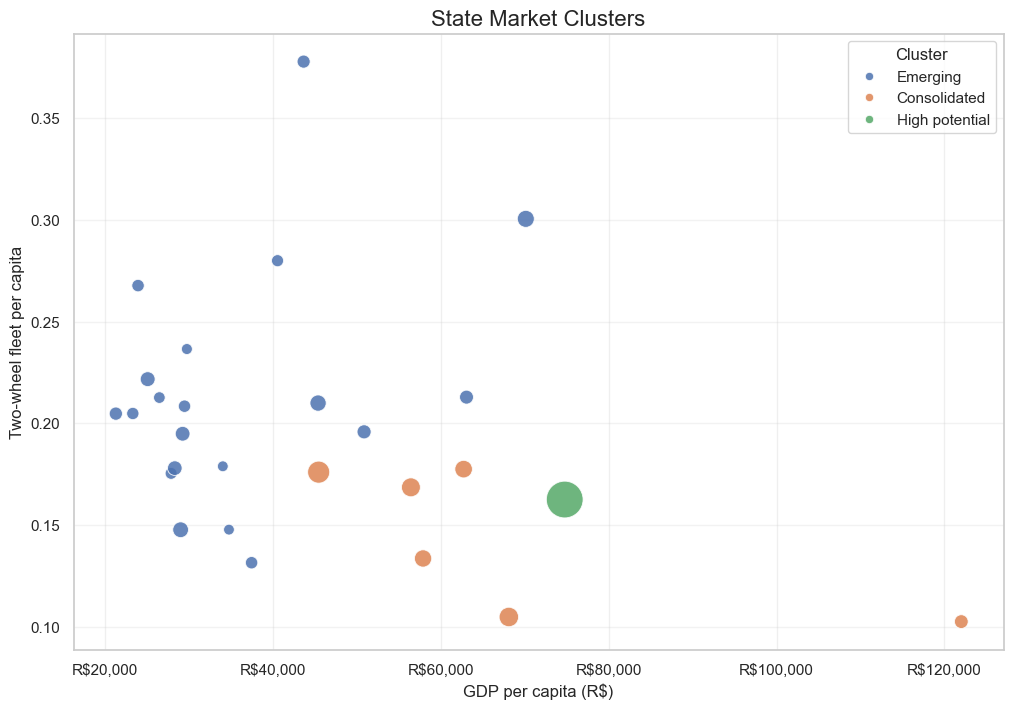

In [65]:
plt.figure(
    figsize=(12, 8)
)

ax = sns.scatterplot(
    data=state_snapshot,
    x="gdp_pc",
    y="fleet_pc",
    hue="cluster",
    size="market_size_proxy",
    sizes=(60, 700),
    alpha=0.85,
)

handles, labels = ax.get_legend_handles_labels()

filtered_handles = []
filtered_labels = []

for handle, label in zip(handles, labels):

    if label in state_snapshot["cluster"].unique():

        filtered_handles.append(handle)
        filtered_labels.append(label)

ax.legend(
    filtered_handles,
    filtered_labels,
    title="Cluster",
)

ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter(
        "R${x:,.0f}"
    )
)

plt.title(
    "State Market Clusters",
    fontsize=16,
)

plt.xlabel(
    "GDP per capita (R$)"
)

plt.ylabel(
    "Two-wheel fleet per capita"
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.show()

> Interpretation
> * The visualization shows a clear separation between large-scale mature markets and smaller mobility-intensive states.
> * São Paulo appears as a unique large-scale market profile due to its exceptional market-size proxy.
> * Consolidated states generally combine stronger purchasing power with moderate mobility intensity.
> * Emerging states tend to display smaller market scale but relatively high two-wheel mobility intensity, suggesting meaningful structural readiness even outside the largest economic centers.

## 11.3 Cluster Summary

This step summarizes each cluster by number of states and average structural indicators.

The goal is to translate the K-Means output into a readable market segmentation framework, showing how each group differs in economic readiness, mobility intensity, and opportunity scale.

In [67]:
cluster_summary = (
    state_snapshot
    .groupby(
        "cluster",
        as_index=False,
    )
    .agg(
        states=("state", "count"),
        avg_gdp_pc=("gdp_pc", "mean"),
        avg_fleet_pc=("fleet_pc", "mean"),
        avg_market_size_proxy=("market_size_proxy", "mean"),
    )
    .sort_values(
        "avg_market_size_proxy",
        ascending=False,
    )
)

cluster_summary.columns = [
    "Cluster",
    "States",
    "Avg GDP per capita",
    "Avg Fleet per capita",
    "Avg Market Opportunity Proxy",
]

display(
    cluster_summary
    .style
    .format(
        {
            "Avg GDP per capita": "R${:,.0f}",
            "Avg Fleet per capita": "{:.3f}",
            "Avg Market Opportunity Proxy": "{:,.0f}",
        }
    )
    .hide(axis="index")
)

Cluster,States,Avg GDP per capita,Avg Fleet per capita,Avg Market Opportunity Proxy
High potential,1,"R$74,754",0.162,"559,586,524"
Consolidated,6,"R$68,759",0.144,"103,679,635"
Emerging,20,"R$35,660",0.214,"32,535,429"


> Interpretation
> * The High potential segment is represented exclusively by São Paulo, reflecting its exceptional structural market scale.
> * Consolidated states combine stronger purchasing power with moderate mobility intensity, forming the most mature market profile outside São Paulo.
> * Emerging states show lower average economic scale but higher average two-wheel mobility intensity, suggesting relevant long-term expansion potential in mobility-oriented markets.

## 11.4 Cluster Membership and Interpretation

The clustering results suggest that Brazilian states can be grouped into distinct structural market profiles rather than a single homogeneous market.

### High potential

| State | Region | Main Characteristics |
|---|---|---|
| São Paulo | Southeast | Exceptional market scale, strong purchasing power, and large mobility infrastructure |

São Paulo forms a unique standalone segment due to its overwhelming structural scale relative to all other states in the dataset.

---

### Consolidated Markets

| State | Region | Main Characteristics |
|---|---|---|
| Minas Gerais | Southeast | Large mature market with balanced mobility intensity |
| Rio de Janeiro | Southeast | High purchasing power and strong urban concentration |
| Paraná | South | Mature mobility-oriented market |
| Santa Catarina | South | High income and strong mobility readiness |
| Rio Grande do Sul | South | Consolidated southern market profile |
| Distrito Federal | Center-West | Extremely high purchasing power but smaller market scale |

These states combine stronger economic readiness with already established mobility infrastructure, forming the most mature market environments outside São Paulo.

---

### Emerging Markets

| State | Region | Main Characteristics |
|---|---|---|
| Mato Grosso | Center-West | High mobility intensity and strong economic readiness |
| Goiás | Center-West | Balanced emerging market with strong mobility structure |
| Ceará | Northeast | High mobility intensity in a growing regional market |
| Pará | North | Large northern market with meaningful mobility readiness |
| Rondônia | North | Extremely high two-wheel mobility intensity |
| Maranhão | Northeast | Mobility-intensive developing market |

Emerging states generally show lower overall market scale, but many display strong structural familiarity with two-wheel transportation behavior.

This suggests that long-term scooter expansion in Brazil may emerge not only from mature large-scale economies, but also from mobility-intensive developing regions.

# 12. Modeling Feasibility

This section evaluates whether the requested regression specification can be estimated reliably with the available data.

The requested model uses:

- target: **imports**
- features: **gdp_pc**, **fleet_pc** and **trends_lead3**

However, after aligning national imports, GDP per capita, fleet per capita, and lagged digital interest, the available dataset contains only a very small number of comparable annual observations.

Because of this, the goal of this section is not to force a statistically unreliable regression model, but to transparently evaluate whether the modeling requirement is supported by the data.

## 12.1 Requested Regression Specification

This step builds the aligned dataset required for the requested regression model.

The model specification is preserved exactly as requested, but the notebook validates whether the available data is sufficient before fitting the model.

In [71]:
gdp_brazil = (
    gdp_long.loc[
        gdp_long["state_norm"] == "BRASIL",
        [
            "year",
            "gdp",
        ],
    ]
    .copy()
)

# National references
population_brazil = 213_421_037
fleet_brazil = 37_221_728

model_df = (
    market_national
    .merge(
        gdp_brazil,
        on="year",
        how="left",
    )
)

model_df["gdp_pc"] = (
    model_df["gdp"] * 1000
    / population_brazil
)

model_df["fleet_pc"] = (
    fleet_brazil
    / population_brazil
)

model_df = (
    model_df[
        [
            "year",
            "imports",
            "gdp_pc",
            "fleet_pc",
            "trends_lead3",
        ]
    ]
    .dropna()
    .copy()
)

display(
    model_df
    .style
    .format(
        {
            "imports": "{:,.0f}",
            "gdp_pc": "R${:,.0f}",
            "fleet_pc": "{:.3f}",
            "trends_lead3": "{:.1f}",
        }
    )
    .hide(axis="index")
)

year,imports,gdp_pc,fleet_pc,trends_lead3
2022,"157,487","R$47,229",0.174,20.3
2023,"196,783","R$51,276",0.174,16.7


> Interpretation
> * The aligned modeling dataset contains only the years where all requested variables are available simultaneously.
> * This creates a very small modeling sample, which makes statistical regression unreliable.
> * The dataset is useful for validating feasibility, but not sufficient for meaningful predictive modeling.

## 12.2 Regression Feasibility Check

This step checks whether the aligned dataset contains enough observations to estimate the requested regression model responsibly.

Rather than fitting a model with insufficient data, the notebook reports the limitation explicitly.

In [74]:
minimum_required_observations = 4

if len(model_df) >= minimum_required_observations:

    X = model_df[
        [
            "gdp_pc",
            "fleet_pc",
            "trends_lead3",
        ]
    ]

    y = model_df["imports"]

    reg = LinearRegression().fit(
        X,
        y,
    )

    preds = reg.predict(X)

    regression_results = pd.DataFrame(
        {
            "Feature": X.columns,
            "Coefficient": reg.coef_,
        }
    )

    display(
        regression_results
        .style
        .format(
            {
                "Coefficient": "{:,.3f}",
            }
        )
        .hide(axis="index")
    )

    print(
        f"R²: {r2_score(y, preds):.3f}"
    )

> **Modeling Feasibility Result**
>
> The aligned dataset contains only **2 comparable annual observations** after combining:
>
> - imports
> - GDP per capita
> - fleet per capita
> - and lagged digital interest.
>
> Because of this, the requested regression specification cannot be estimated responsibly with the current source files.
>
> Fitting a regression model with such a small sample would produce unreliable coefficients and misleading evaluation metrics.

# 13. Hypothesis Validation

This section evaluates the original business hypotheses proposed for the project using the available national and regional datasets.

Because the source files do not contain observed scooter adoption by state, some hypotheses can only be evaluated indirectly through structural proxies and exploratory relationships.

The goal of this section is therefore not to claim definitive causal validation, but to assess whether the available evidence supports, contradicts, or fails to test each proposed hypothesis.

## 13.1 Hypothesis Testing Framework

The original project specification proposed four business hypotheses related to market growth, economic readiness, mobility behavior, and digital demand.

Each hypothesis is evaluated according to:
- the availability of compatible data
- the analytical methods developed throughout the notebook
- and the reliability of the resulting evidence.

## 13.2 Hypothesis Evaluation

| Hypothesis | Evaluation | Main Evidence |
|---|---|---|
| **H1** — Google Trends increases precede market growth by 3–6 periods | **Partially supported** | Lagged Google Trends indicators maintain very strong positive correlations with realized imports (**0.946** for 3-month lead and **0.967** for 6-month lead), although the lagged sample contains only four comparable observations |
| **H2** — GDP has a positive correlation with absolute adoption | **Inconclusive with current data** | GDP is strongly associated with the engineered market-opportunity proxy, but the dataset does not include observed scooter adoption by state |
| **H3** — Lower GDP states show higher relative growth | **Not testable with current data** | The project does not contain state-level scooter adoption time series required to measure relative growth dynamics |
| **H4** — Motorcycle fleet is positively correlated with scooter adoption | **Inconclusive with current data** | Two-wheel fleet indicators are strongly associated with structural market opportunity, but not with directly observed scooter adoption |

## 13.3 Overall Validation Summary

The strongest evidence produced in this project supports the idea that digital demand signals may precede periods of accelerated market expansion.

At the same time, the analysis also reveals an important structural limitation of the available datasets: most regional indicators describe economic readiness and mobility infrastructure rather than observed scooter adoption itself.

Because of this, the project is strongest as:
- a market-intelligence analysis
- an exploratory structural study
- and a demand-readiness assessment

rather than as a definitive adoption forecasting framework.

Even with these limitations, the evidence remains highly coherent across:
- imports
- digital demand
- regional mobility intensity
- economic concentration
- and clustering segmentation results.

# 14. Final Insights

This final section consolidates the main business and analytical insights developed throughout the project.

Rather than introducing new analysis, the goal is to synthesize:
- market-growth dynamics
- digital demand behavior
- regional opportunity patterns
- and structural market-readiness signals.

The project ultimately functions as a market-intelligence and opportunity-mapping framework for the Brazilian electric scooter market.

## 14.1 Executive Findings

### Main Market Conclusions

1. The electric scooter market shows clear acceleration in Brazil, especially between 2024 and 2025.
2. Digital demand indicators are the strongest observable leading signals in the current dataset.
3. Falling average import prices appear closely associated with periods of rapid market expansion.
4. Market opportunity is distributed across both:
   - large mature economies;
   - and mobility-intensive emerging regions.
5. Two-wheel mobility culture appears to be an important structural readiness factor outside the largest economic centers.

### Strongest Opportunity States

- São Paulo
- Minas Gerais
- Mato Grosso
- Rio de Janeiro
- Paraná

### Regional Opportunity Lenses

- **Southeast** → economic scale and purchasing power
- **Center-West** → mobility intensity and transportation culture
- **Northeast** → large two-wheel base and emerging structural demand

## 14.2 Strategic Opportunity Interpretation

The analysis suggests that the Brazilian electric scooter market may evolve through multiple parallel expansion pathways rather than through a single homogeneous adoption pattern.

Large-scale mature markets such as São Paulo, Minas Gerais, Rio de Janeiro, and Paraná appear structurally important due to:
- purchasing power
- urban concentration
- and economic scale

At the same time, several mobility-intensive regions — especially in the Center-West, North, and Northeast — show strong structural familiarity with two-wheel transportation behavior.

This creates an important strategic distinction:

- mature markets may favor premiumization and scale-driven expansion
- while emerging mobility-intensive markets may respond more strongly to affordability and practical transportation value.

The strongest observable predictive indicators identified in this project are:
- rising Google Trends levels
- lead digital-demand acceleration
- falling import prices
- and high two-wheel fleet intensity.

## 14.3 Project Limitations and Future Improvements

The largest limitation of the current project is the absence of observed scooter adoption data at the state level.

Because of this, much of the regional analysis relies on:
- structural opportunity proxies
- economic readiness indicators
- and mobility-intensity measures

rather than directly observed consumption behavior.

A richer state-level adoption dataset would substantially strengthen:
- explanatory modeling
- predictive forecasting
- causal validation
- and regional demand estimation.

Future improvements could include:
- state-level scooter registration data
- dealer or sales data
- municipal adoption indicators
- charging infrastructure information
- and longitudinal regional demand tracking.